In [8]:
import xarray as xr
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_1_onestep_l1_nofc_aheadtop_0.5/prcp_downs_unet_year_2020.nc")
ds

<xarray.Dataset>
Dimensions:    (time: 6912, lat_in: 16, lon_in: 16, lat: 160, lon: 160,
                pitch_idx: 6912)
Coordinates:
  * time       (time) datetime64[ns] 2020-02-01T06:00:00 ... 2020-12-01T02:00:00
  * pitch_idx  (pitch_idx) int32 1 2 3 4 5 6 7 ... 6907 6908 6909 6910 6911 6912
Dimensions without coordinates: lat_in, lon_in, lat, lon
Data variables:
    inputs     (time, lat_in, lon_in) float32 ...
    inter      (time, lat, lon) float32 ...
    fcst       (time, lat, lon) float32 ...
    hr         (time, lat, lon) float32 ...
    lats       (time, lat) float32 ...
    lons       (time, lon) float32 ...
    tops       (time, lat, lon) float32 ...
Attributes:
    description:  Precipitation downscaling data.

In [31]:
import xarray as xr
import numpy as np

# 打开数据集
ds = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_1_onestep_l1_nofc_aheadtop_0.5/prcp_downs_unet_year_2020.nc")

# 提取 'hr' 变量
hr = ds['hr']

# 将数据展开为一维数组
hr_values = hr.values.flatten()

# 移除 NaN 值
hr_values = hr_values[~np.isnan(hr_values)]

# 定义区间
bins = [0, 1.5, 7.5, 15, np.inf]

# 计算每个区间的像素数量
counts, _ = np.histogram(hr_values, bins=bins)

# 计算总像素数量
total_pixels = counts.sum()

# 计算百分比
percentages = counts / total_pixels * 100

# 打印结果
intervals = ["0-1.5", "1.5-7.5", "7.5-15", "15以上"]
for interval, percentage in zip(intervals, percentages):
    print(f"区间 {interval} mm: {percentage:.2f}%")


区间 0-1.5 mm: 89.74%
区间 1.5-7.5 mm: 10.10%
区间 7.5-15 mm: 0.15%
区间 15以上 mm: 0.01%


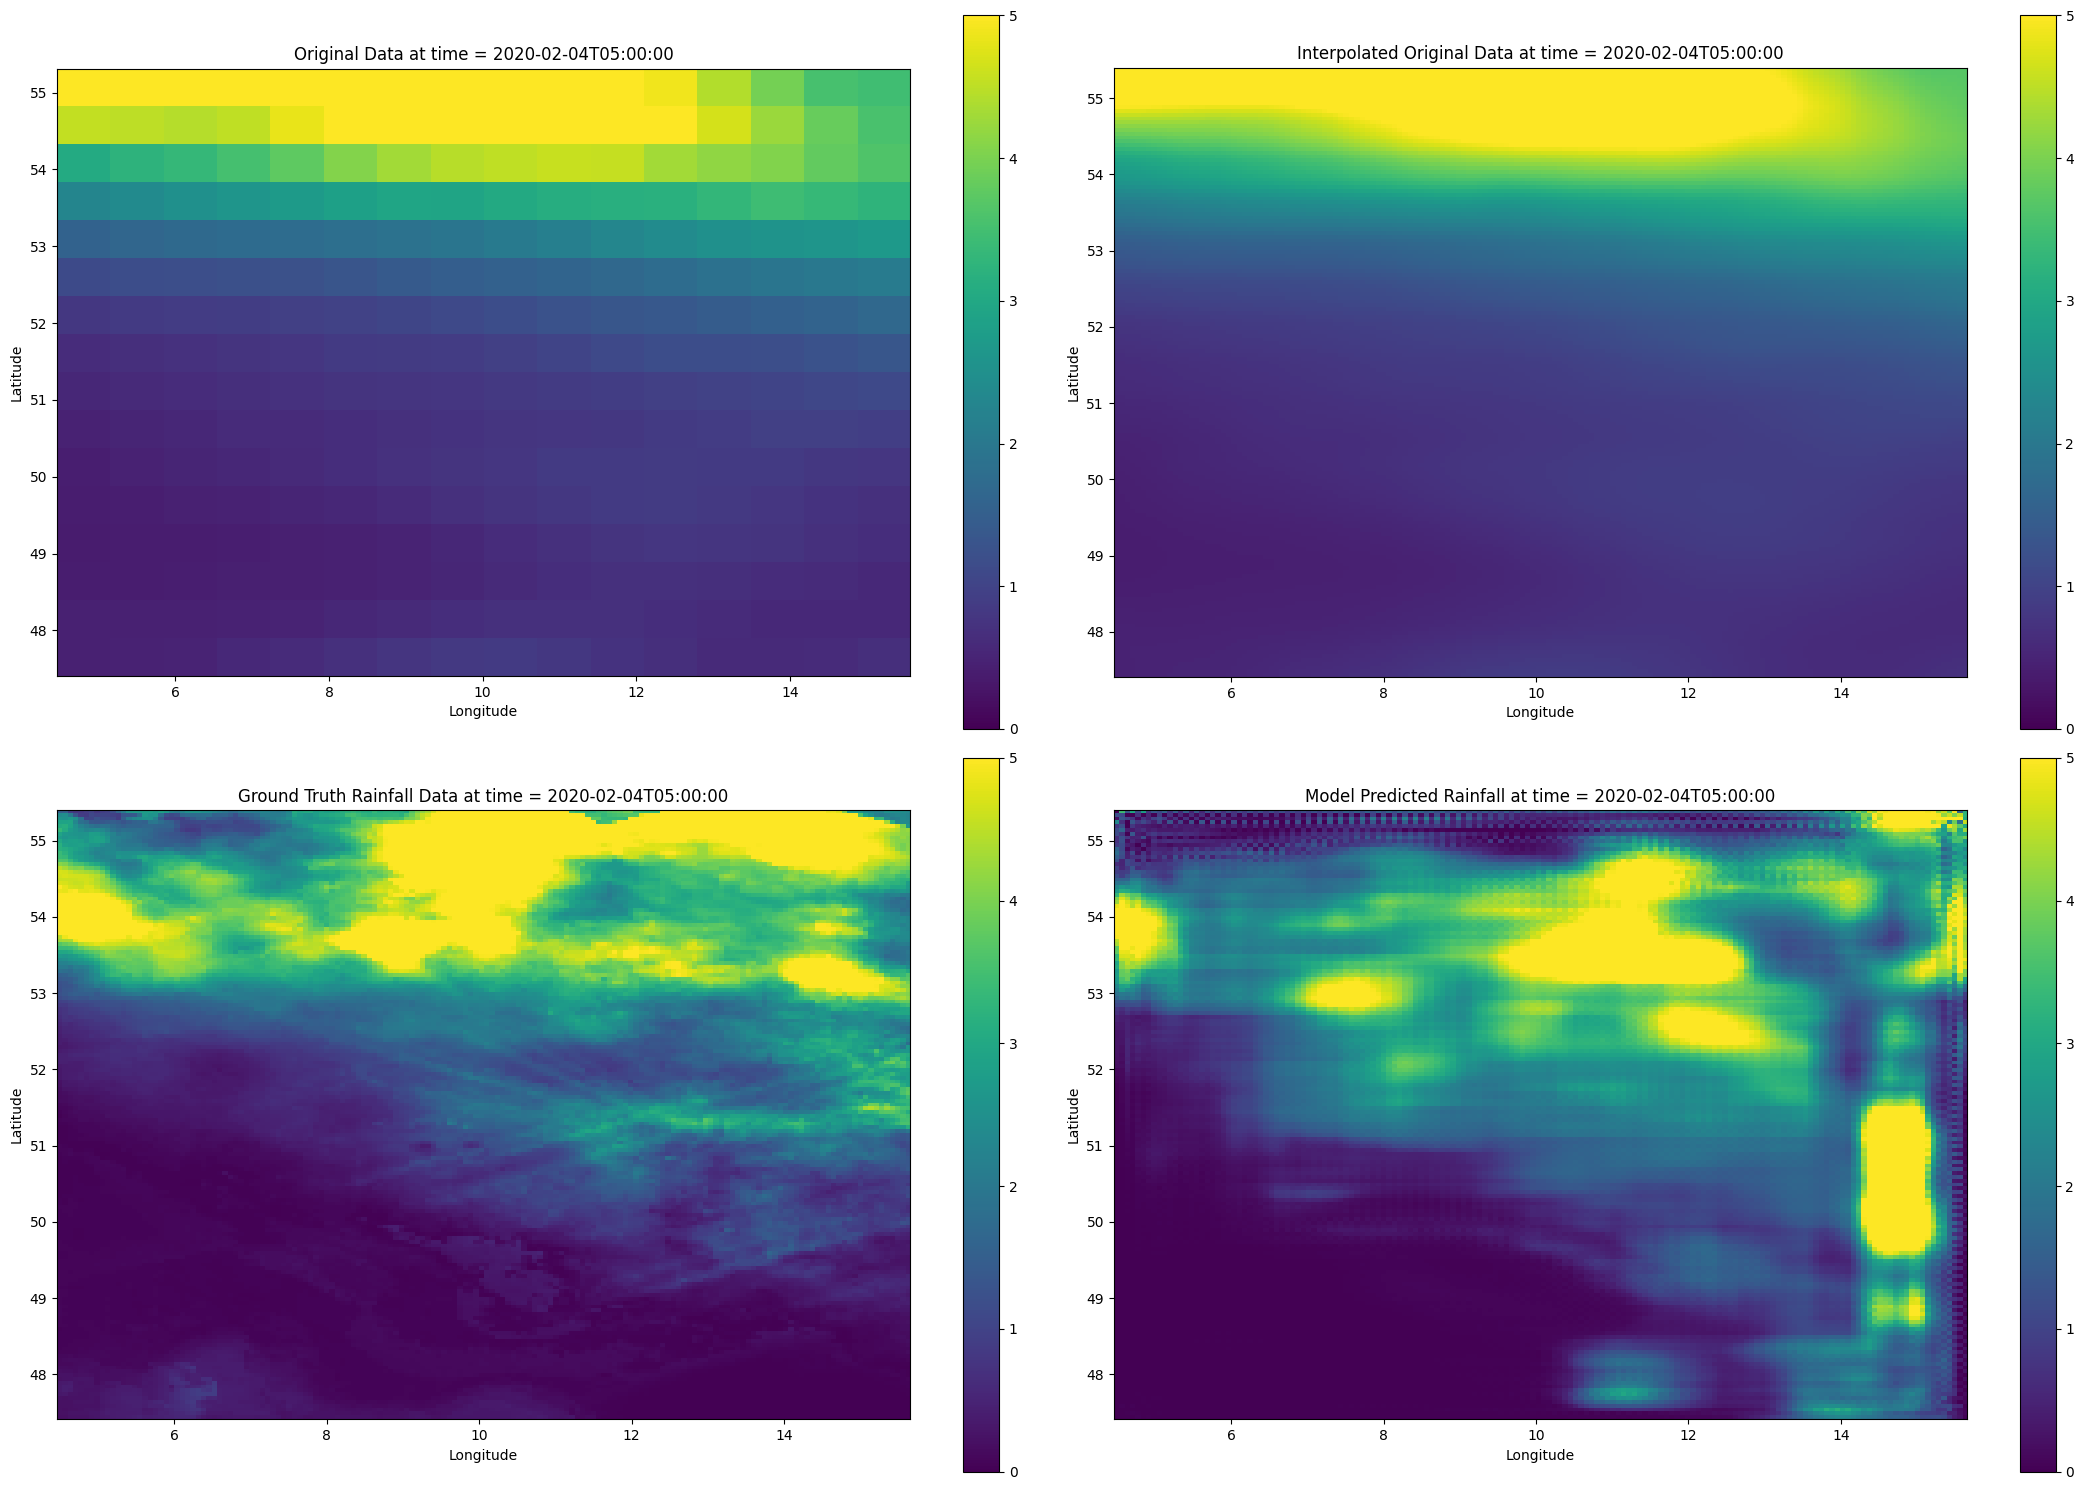

In [20]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# 加载数据集
dn = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex14_3_onestep_weightmae_aheadtop_10_addprecipnorm_15_6_60_120/prcp_downs_unet_year_2020.nc")
time_index = 380 #642 6236 6237 6243 6247 6260 6271 6291 6309 6311 6320 6328 3839 380            3740附近   640附近     #4005  #650 380 3600 4500 30 60 460 920 1660 2420 2780 2940 3020 3080 3920 5190 5410 2940 650
time = pd.to_datetime(dn["time"].values[time_index]).isoformat()

# 提取高分辨率经纬度
lats_hr = dn["lats"].values  # 160x160的纬度
lons_hr = dn["lons"].values  # 160x160的经度

# 生成低分辨率经纬度（通过等间隔下采样，适用于16x16的inputs）
lats_in = lats_hr[::10, ::10]  # 每隔10个点取一个，160/16=10
lons_in = lons_hr[::10, ::10]

# 创建两行两列的图布局
fig, axes = plt.subplots(2, 2, figsize=(22, 15))

# 第一个图：原始数据 (低分辨率16x16)
im1 = axes[0, 0].imshow(dn["inputs"].isel(time=time_index).values, vmin=0, vmax=5,
                        extent=[lons_in.min(), lons_in.max(), lats_in.min(), lats_in.max()])
axes[0, 0].set_title(f'Original Data at time = {time}')
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')
fig.colorbar(im1, ax=axes[0, 0])

# 第二个图：插值数据 (高分辨率160x160)
im2 = axes[0, 1].imshow(dn["inter"].isel(time=time_index).values, vmin=0, vmax=5,
                        extent=[lons_hr.min(), lons_hr.max(), lats_hr.min(), lats_hr.max()])
axes[0, 1].set_title(f'Interpolated Original Data at time = {time}')
axes[0, 1].set_xlabel('Longitude')
axes[0, 1].set_ylabel('Latitude')
fig.colorbar(im2, ax=axes[0, 1])

# 第三个图：真实数据 (高分辨率160x160)
im3 = axes[1, 0].imshow(dn["hr"].isel(time=time_index).values, vmin=0, vmax=5,
                        extent=[lons_hr.min(), lons_hr.max(), lats_hr.min(), lats_hr.max()])
axes[1, 0].set_title(f'Ground Truth Rainfall Data at time = {time}')
axes[1, 0].set_xlabel('Longitude')
axes[1, 0].set_ylabel('Latitude')
fig.colorbar(im3, ax=axes[1, 0])

# 第四个图：模型预测 (高分辨率160x160)
im4 = axes[1, 1].imshow(dn["fcst"].isel(time=time_index).values, vmin=0, vmax=5,
                        extent=[lons_hr.min(), lons_hr.max(), lats_hr.min(), lats_hr.max()])
axes[1, 1].set_title(f'Model Predicted Rainfall at time = {time}')
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')
fig.colorbar(im4, ax=axes[1, 1])

plt.tight_layout()
plt.show()


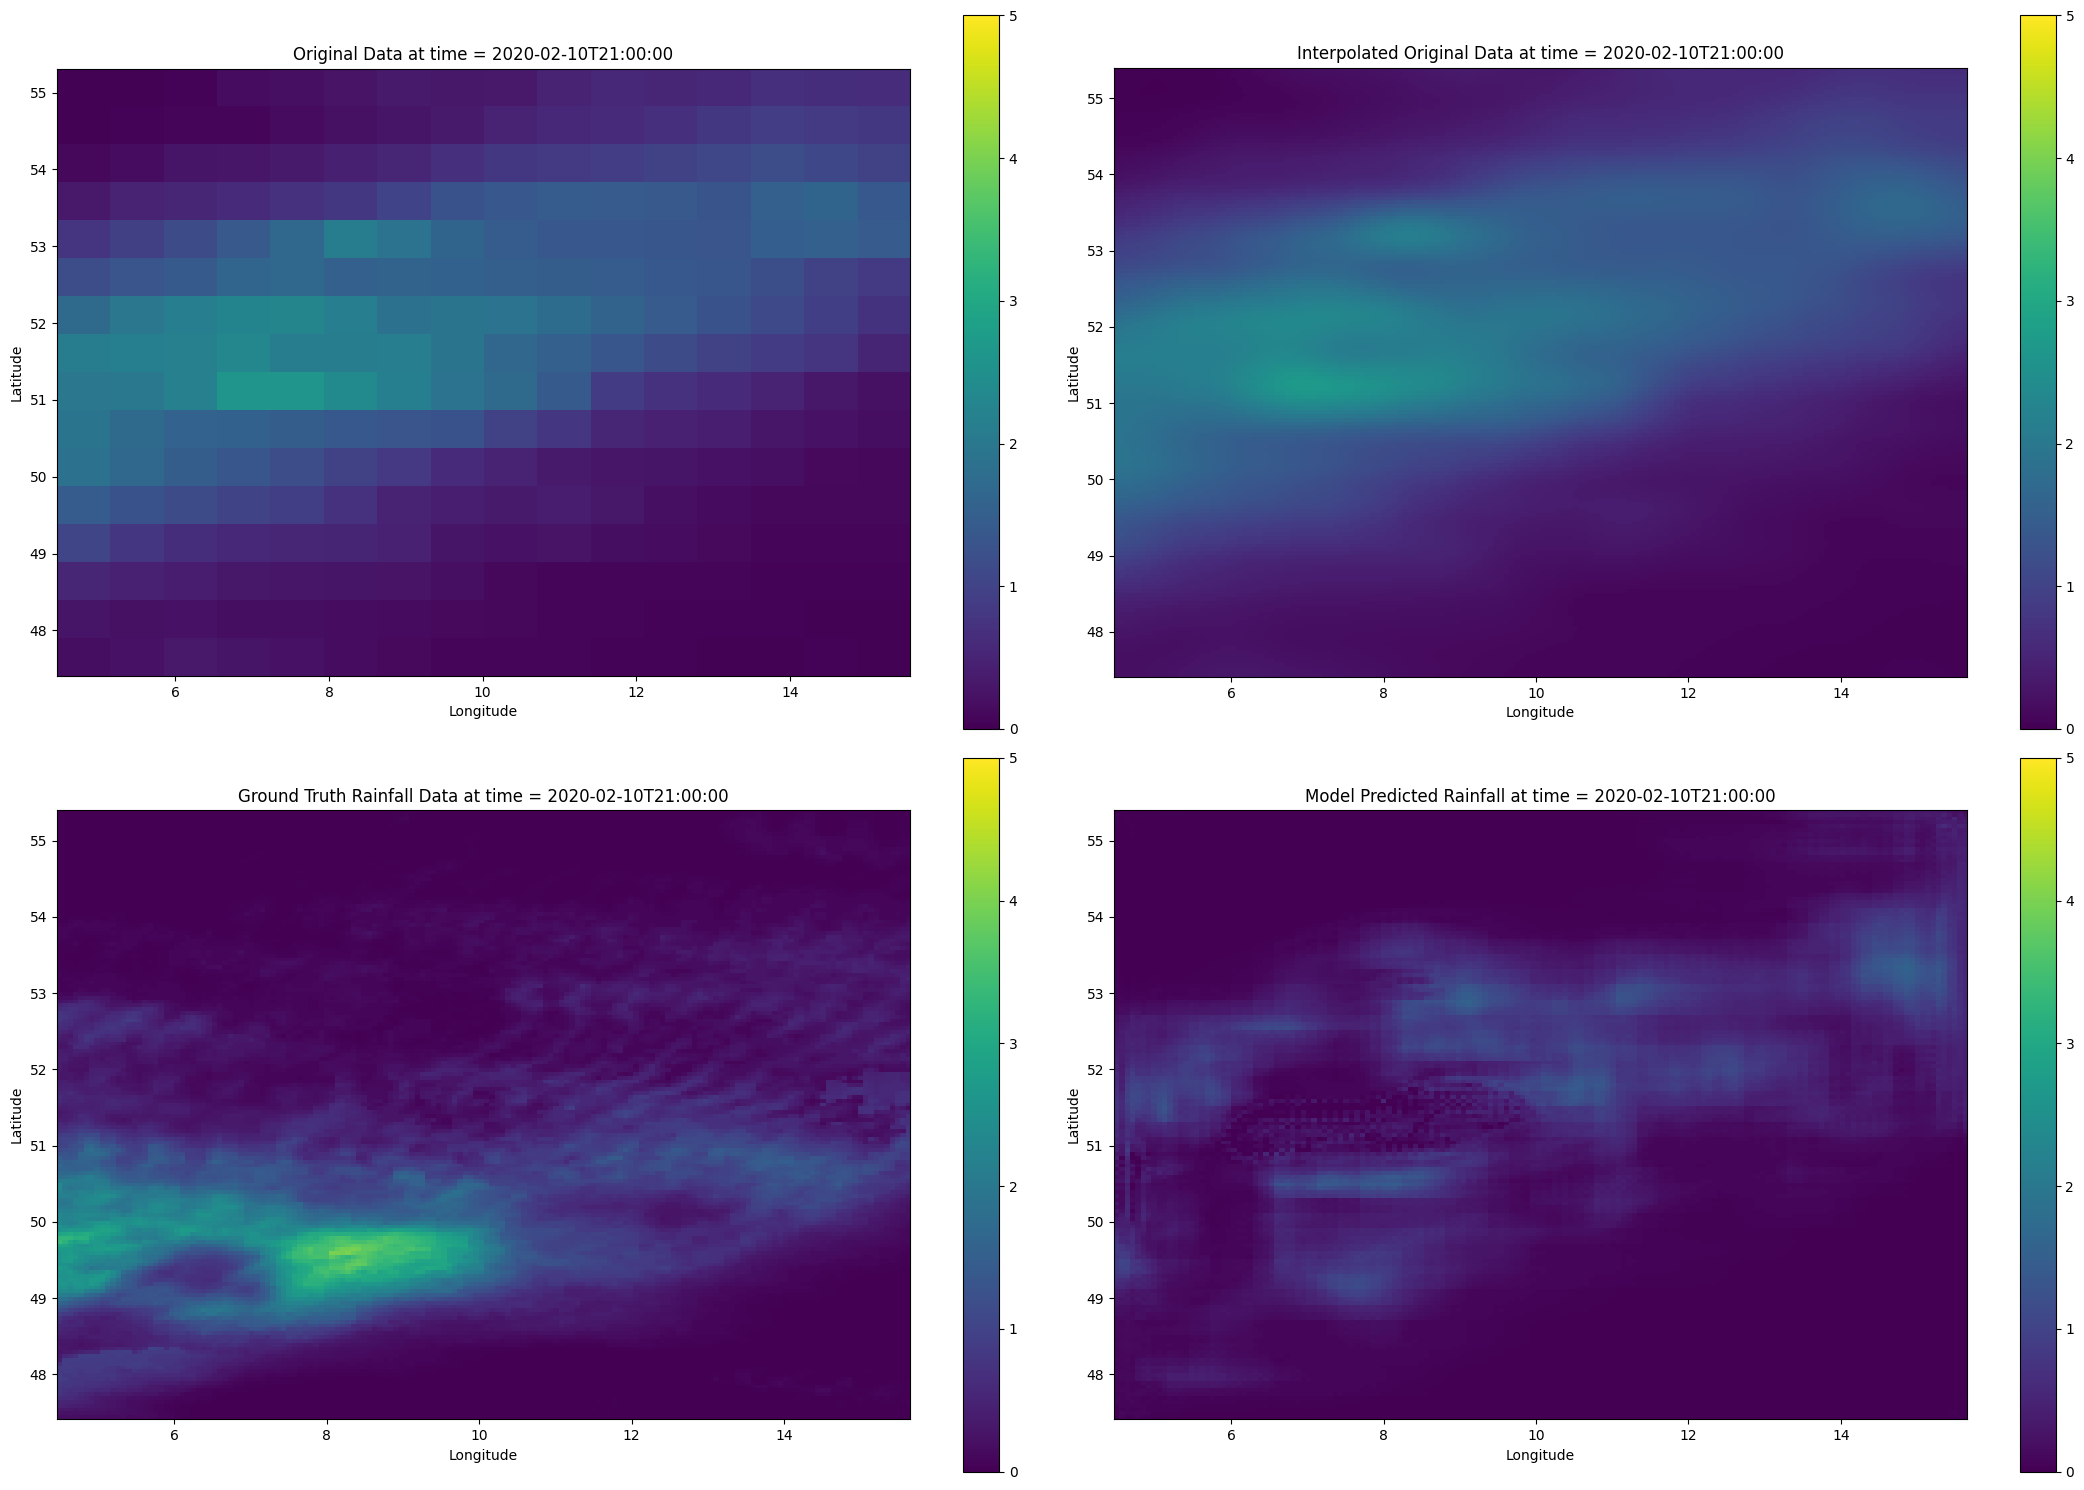

In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# 加载数据集
dn = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_4_onestep_l1_nofc_aheadtop_10/prcp_downs_unet_year_2020.nc")
time_index = 642  #530 290 610 580 350 6200 5000     #650 380 3600 4500 30 60 460 920 1660 2420 2780 2940 3020 3080 3920 5190 5410 2940 650
time = pd.to_datetime(dn["time"].values[time_index]).isoformat()

# 提取高分辨率经纬度
lats_hr = dn["lats"].values  # 160x160的纬度
lons_hr = dn["lons"].values  # 160x160的经度

# 生成低分辨率经纬度（通过等间隔下采样，适用于16x16的inputs）
lats_in = lats_hr[::10, ::10]  # 每隔10个点取一个，160/16=10
lons_in = lons_hr[::10, ::10]

# 创建两行两列的图布局
fig, axes = plt.subplots(2, 2, figsize=(22, 15))

# 第一个图：原始数据 (低分辨率16x16)
im1 = axes[0, 0].imshow(dn["inputs"].isel(time=time_index).values, vmin=0, vmax=5,
                        extent=[lons_in.min(), lons_in.max(), lats_in.min(), lats_in.max()])
axes[0, 0].set_title(f'Original Data at time = {time}')
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')
fig.colorbar(im1, ax=axes[0, 0])

# 第二个图：插值数据 (高分辨率160x160)
im2 = axes[0, 1].imshow(dn["inter"].isel(time=time_index).values, vmin=0, vmax=5,
                        extent=[lons_hr.min(), lons_hr.max(), lats_hr.min(), lats_hr.max()])
axes[0, 1].set_title(f'Interpolated Original Data at time = {time}')
axes[0, 1].set_xlabel('Longitude')
axes[0, 1].set_ylabel('Latitude')
fig.colorbar(im2, ax=axes[0, 1])

# 第三个图：真实数据 (高分辨率160x160)
im3 = axes[1, 0].imshow(dn["hr"].isel(time=time_index).values, vmin=0, vmax=5,
                        extent=[lons_hr.min(), lons_hr.max(), lats_hr.min(), lats_hr.max()])
axes[1, 0].set_title(f'Ground Truth Rainfall Data at time = {time}')
axes[1, 0].set_xlabel('Longitude')
axes[1, 0].set_ylabel('Latitude')
fig.colorbar(im3, ax=axes[1, 0])

# 第四个图：模型预测 (高分辨率160x160)
im4 = axes[1, 1].imshow(dn["fcst"].isel(time=time_index).values, vmin=0, vmax=5,
                        extent=[lons_hr.min(), lons_hr.max(), lats_hr.min(), lats_hr.max()])
axes[1, 1].set_title(f'Model Predicted Rainfall at time = {time}')
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')
fig.colorbar(im4, ax=axes[1, 1])

plt.tight_layout()
plt.show()


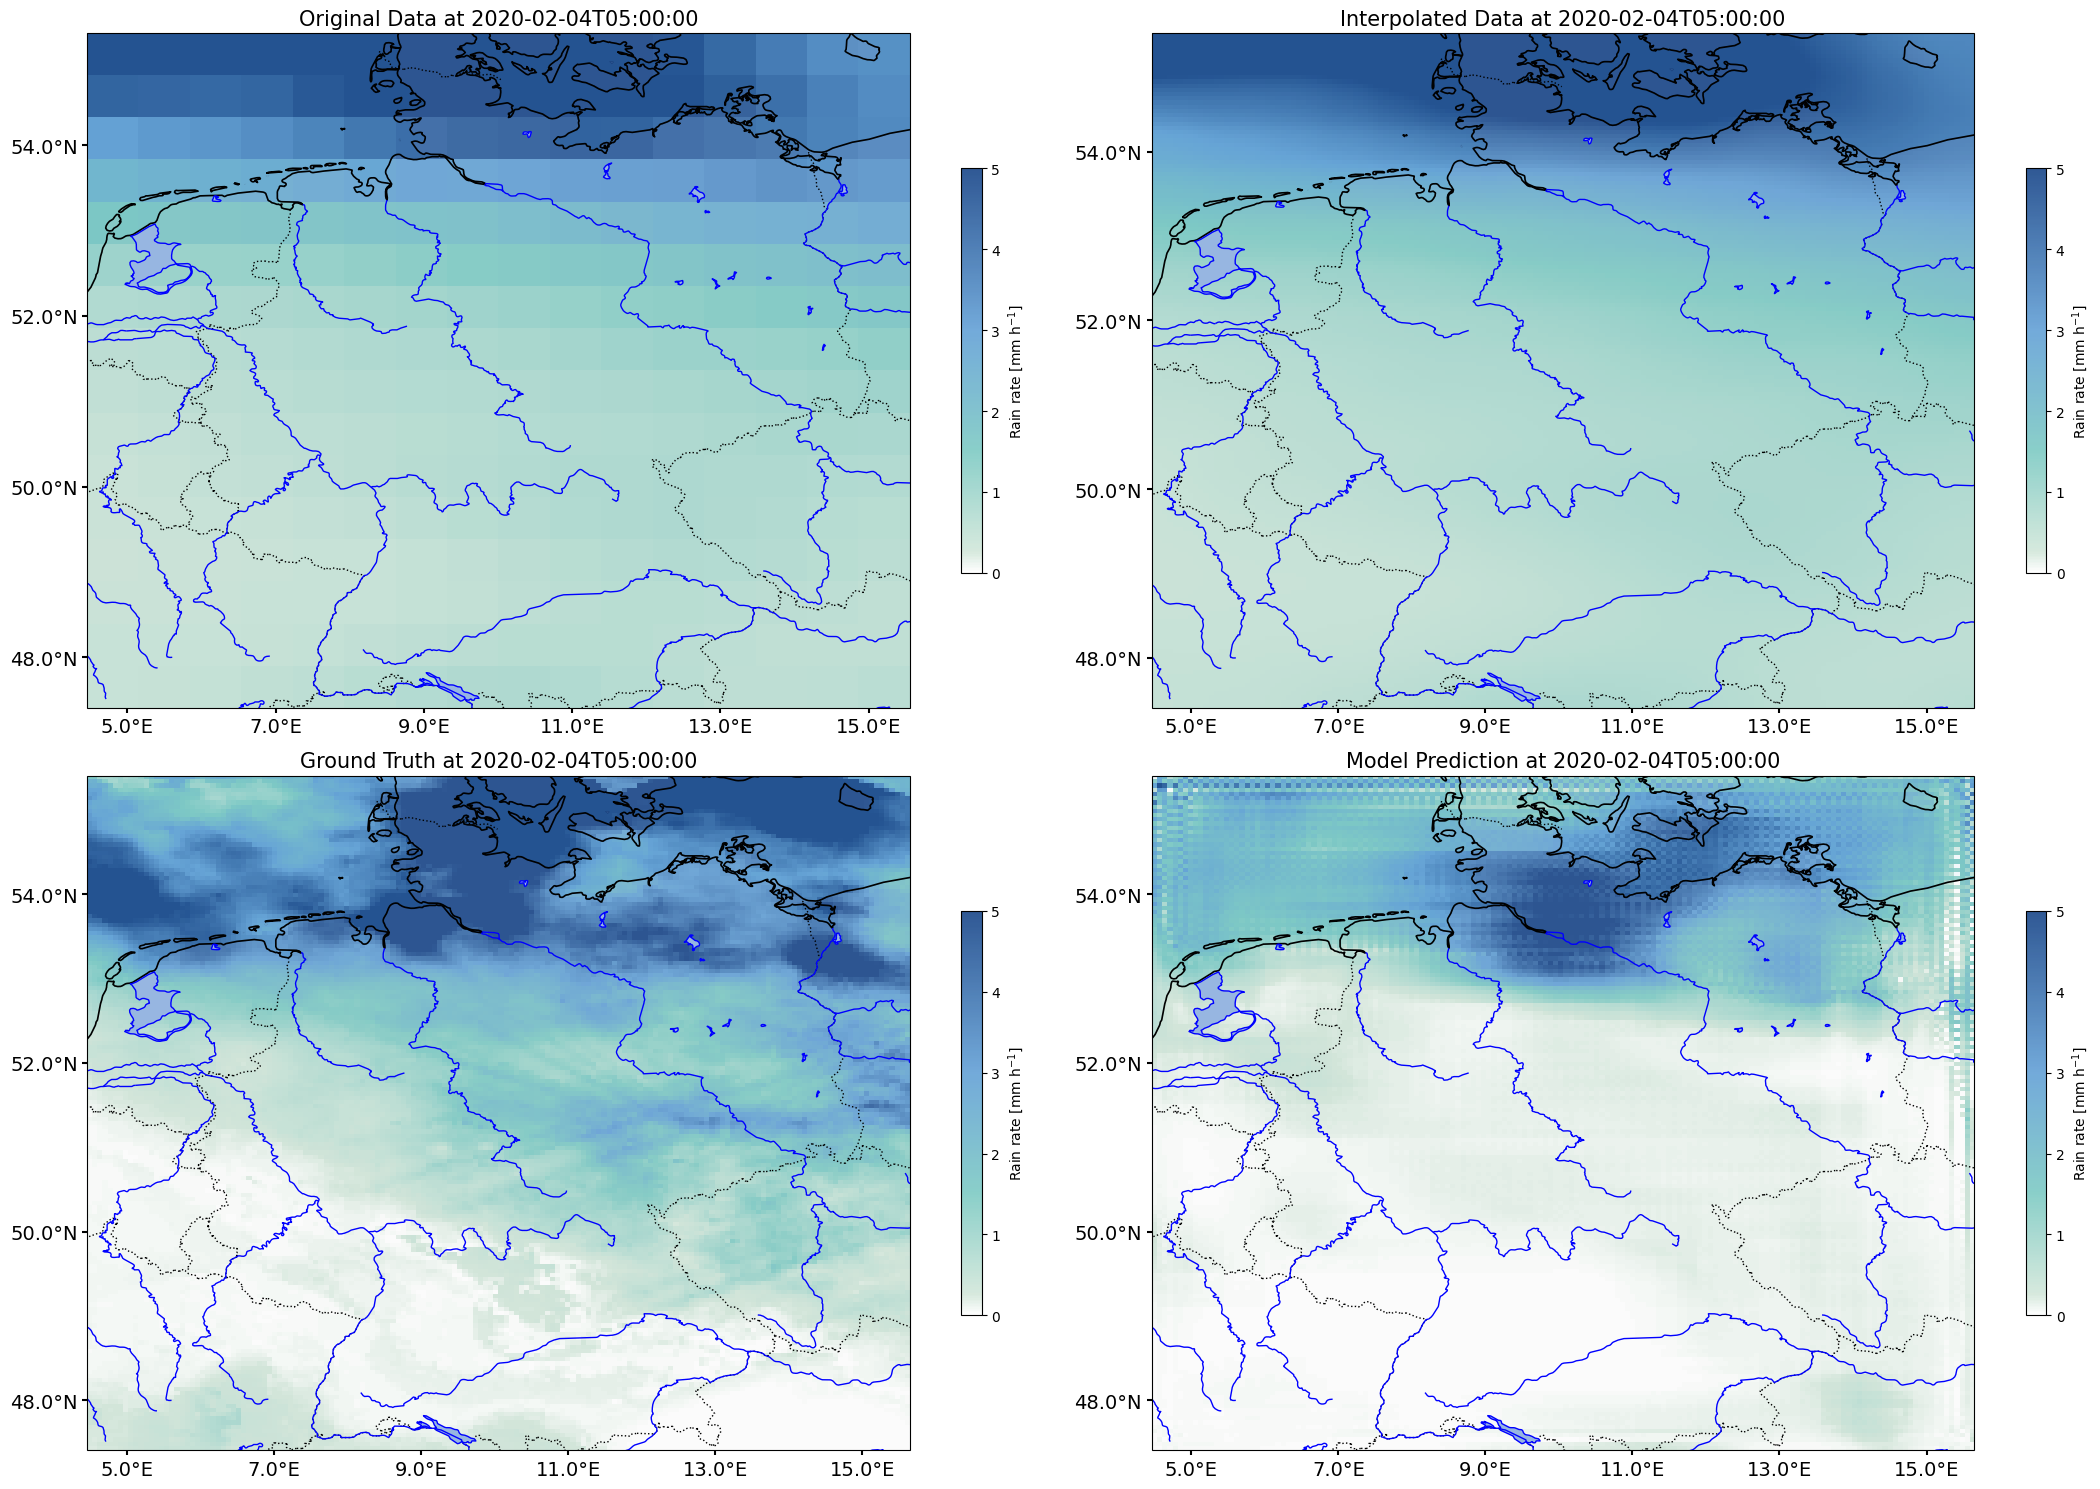

In [29]:
import xarray as xr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import LinearSegmentedColormap

# 加载数据集
dn = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_13_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")
time_index = 380  #642 6236 6237 6243 6247 6260 6271 6291 6309 6311 6320 6328 3839 380   # 选择时间点
time = pd.to_datetime(dn["time"].values[time_index]).isoformat()

# 提取高分辨率经纬度
lats_hr = dn["lats"].values
lons_hr = dn["lons"].values

# 生成低分辨率经纬度（适用于inputs的16x16）
lats_in = lats_hr[::10, ::10]
lons_in = lons_hr[::10, ::10]

# 创建两行两列的图布局
fig, axes = plt.subplots(2, 2, figsize=(22, 15), subplot_kw={'projection': ccrs.PlateCarree()})

# 自定义渐变配色方案 (修改低降水偏白，高降水更深蓝)
colors = [
    (0, "#ffffff"),  # 纯白色 0 - 0.05 mm/h
    (0.05, "#d0e6d8"),  # 浅青绿色 0.05 - 0.5 mm/h
    (0.3, "#76c7c0"),  # 深青绿色 0.5 - 2 mm/h
    (0.6, "#5a9bd4"),  # 深蓝色 2 - 10 mm/h
    (1, "#0b3b82")     # 更深蓝色 10 - 30 mm/h
]
custom_cmap = LinearSegmentedColormap.from_list("CustomRainfall", colors)

# 降雨可视化函数
def plot_rainfall(ax, data, lats, lons, title):
    ax.set_extent([lons.min(), lons.max(), lats.min(), lats.max()])
    
    # 添加地理要素
    ax.add_feature(cfeature.COASTLINE, linewidth=1.2)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray', alpha=0.5)
    ax.add_feature(cfeature.LAKES, edgecolor='blue')
    ax.add_feature(cfeature.RIVERS, edgecolor='blue')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
    
    # 绘制降水数据 (自定义渐变配色)
    im = ax.imshow(data, origin='upper', vmin=0, vmax=5,
                   extent=[lons.min(), lons.max(), lats.min(), lats.max()],
                   cmap=custom_cmap, alpha=0.85, aspect='auto')
    
    # 计算整数范围
    lon_start = np.ceil(lons.min())
    lon_end = np.floor(lons.max())
    lat_start = np.ceil(lats.min())
    lat_end = np.floor(lats.max())
    
    # 设置刻度
    ax.set_xticks(np.arange(lon_start, lon_end + 1, 2))
    ax.set_yticks(np.arange(lat_start, lat_end + 1, 2))
    
    # 格式化经纬度标签，添加单位
    ax.set_xticklabels([f'{lon}°E' if lon >= 0 else f'{abs(lon)}°W' 
                        for lon in np.arange(lon_start, lon_end + 1, 2)])
    
    ax.set_yticklabels([f'{lat}°N' if lat >= 0 else f'{abs(lat)}°S' 
                        for lat in np.arange(lat_start, lat_end + 1, 2)])
    
    # 增大刻度字体并加粗刻度线
    ax.tick_params(axis='both', which='major', labelsize=14, width=1.5)

    # 去除X轴和Y轴标签
    ax.set_xlabel("")
    ax.set_ylabel("")
    

    ax.set_title(title, fontsize=15)
    
    # 添加颜色条
    fig.colorbar(im, ax=ax, shrink=0.6, orientation='vertical', label='Rain rate [mm h$^{-1}$]')

# 绘制四个子图
plot_rainfall(axes[0, 0], dn["inputs"].isel(time=time_index).values, lats_in, lons_in, f'Original Data at {time}')
plot_rainfall(axes[0, 1], dn["inter"].isel(time=time_index).values, lats_hr, lons_hr, f'Interpolated Data at {time}')
plot_rainfall(axes[1, 0], dn["hr"].isel(time=time_index).values, lats_hr, lons_hr, f'Ground Truth at {time}')
plot_rainfall(axes[1, 1], dn["fcst"].isel(time=time_index).values, lats_hr, lons_hr, f'Model Prediction at {time}')

plt.tight_layout()
plt.show()


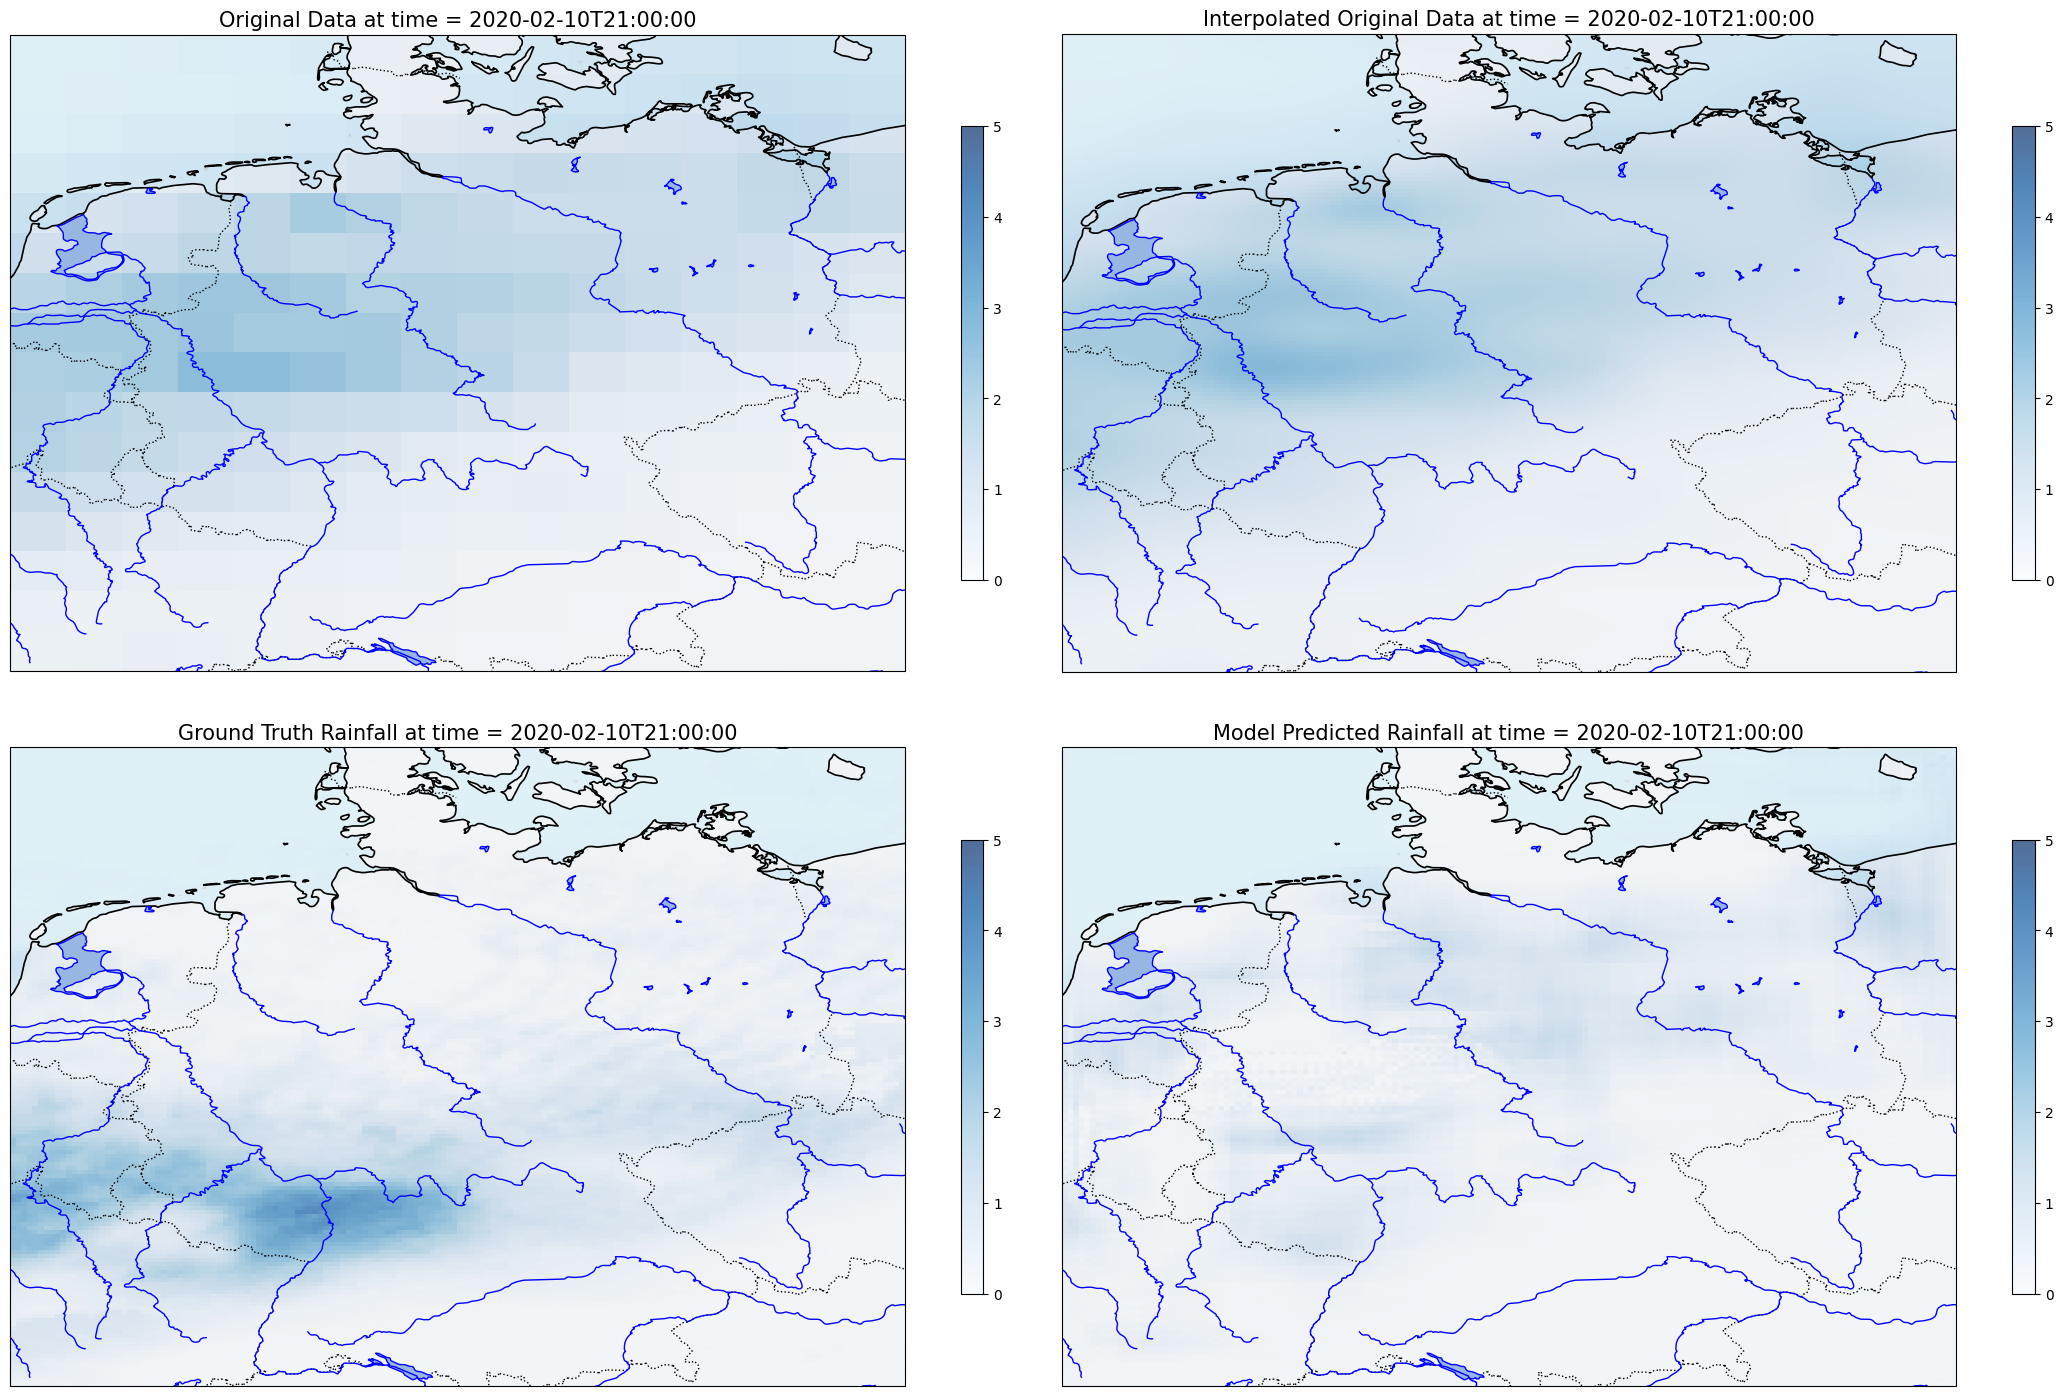

In [5]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 加载数据集
dn = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_4_onestep_l1_nofc_aheadtop_10/prcp_downs_unet_year_2020.nc")
time_index = 642  # 选择时间点
time = pd.to_datetime(dn["time"].values[time_index]).isoformat()

# 提取高分辨率经纬度
lats_hr = dn["lats"].values  # 160x160的纬度
lons_hr = dn["lons"].values  # 160x160的经度

# 生成低分辨率经纬度（适用于inputs的16x16）
lats_in = lats_hr[::10, ::10]
lons_in = lons_hr[::10, ::10]

# 创建两行两列的图布局
fig, axes = plt.subplots(2, 2, figsize=(22, 15), subplot_kw={'projection': ccrs.PlateCarree()})

# 叠加绘制降水和地形图
def plot_rainfall(ax, data, lats, lons, title):
    ax.set_extent([lons.min(), lons.max(), lats.min(), lats.max()])
    ax.add_feature(cfeature.COASTLINE, linewidth=1.2)
    ax.add_feature(cfeature.BORDERS, linestyle=':')
    ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray', alpha=0.5)
    ax.add_feature(cfeature.LAKES, edgecolor='blue')
    ax.add_feature(cfeature.RIVERS, edgecolor='blue')
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue')

    # 绘制降水数据
    im = ax.imshow(data, origin='upper', vmin=0, vmax=5,
                   extent=[lons.min(), lons.max(), lats.min(), lats.max()],
                   cmap='Blues', alpha=0.7)
    
    ax.set_title(title, fontsize=15)
    fig.colorbar(im, ax=ax, shrink=0.6, orientation='vertical')

# 第一个图：原始数据 (低分辨率16x16)
plot_rainfall(axes[0, 0], dn["inputs"].isel(time=time_index).values, lats_in, lons_in,
              f'Original Data at time = {time}')

# 第二个图：插值数据 (高分辨率160x160)
plot_rainfall(axes[0, 1], dn["inter"].isel(time=time_index).values, lats_hr, lons_hr,
              f'Interpolated Original Data at time = {time}')

# 第三个图：真实数据 (高分辨率160x160)
plot_rainfall(axes[1, 0], dn["hr"].isel(time=time_index).values, lats_hr, lons_hr,
              f'Ground Truth Rainfall at time = {time}')

# 第四个图：模型预测 (高分辨率160x160)
plot_rainfall(axes[1, 1], dn["fcst"].isel(time=time_index).values, lats_hr, lons_hr,
              f'Model Predicted Rainfall at time = {time}')

plt.tight_layout()
plt.show()


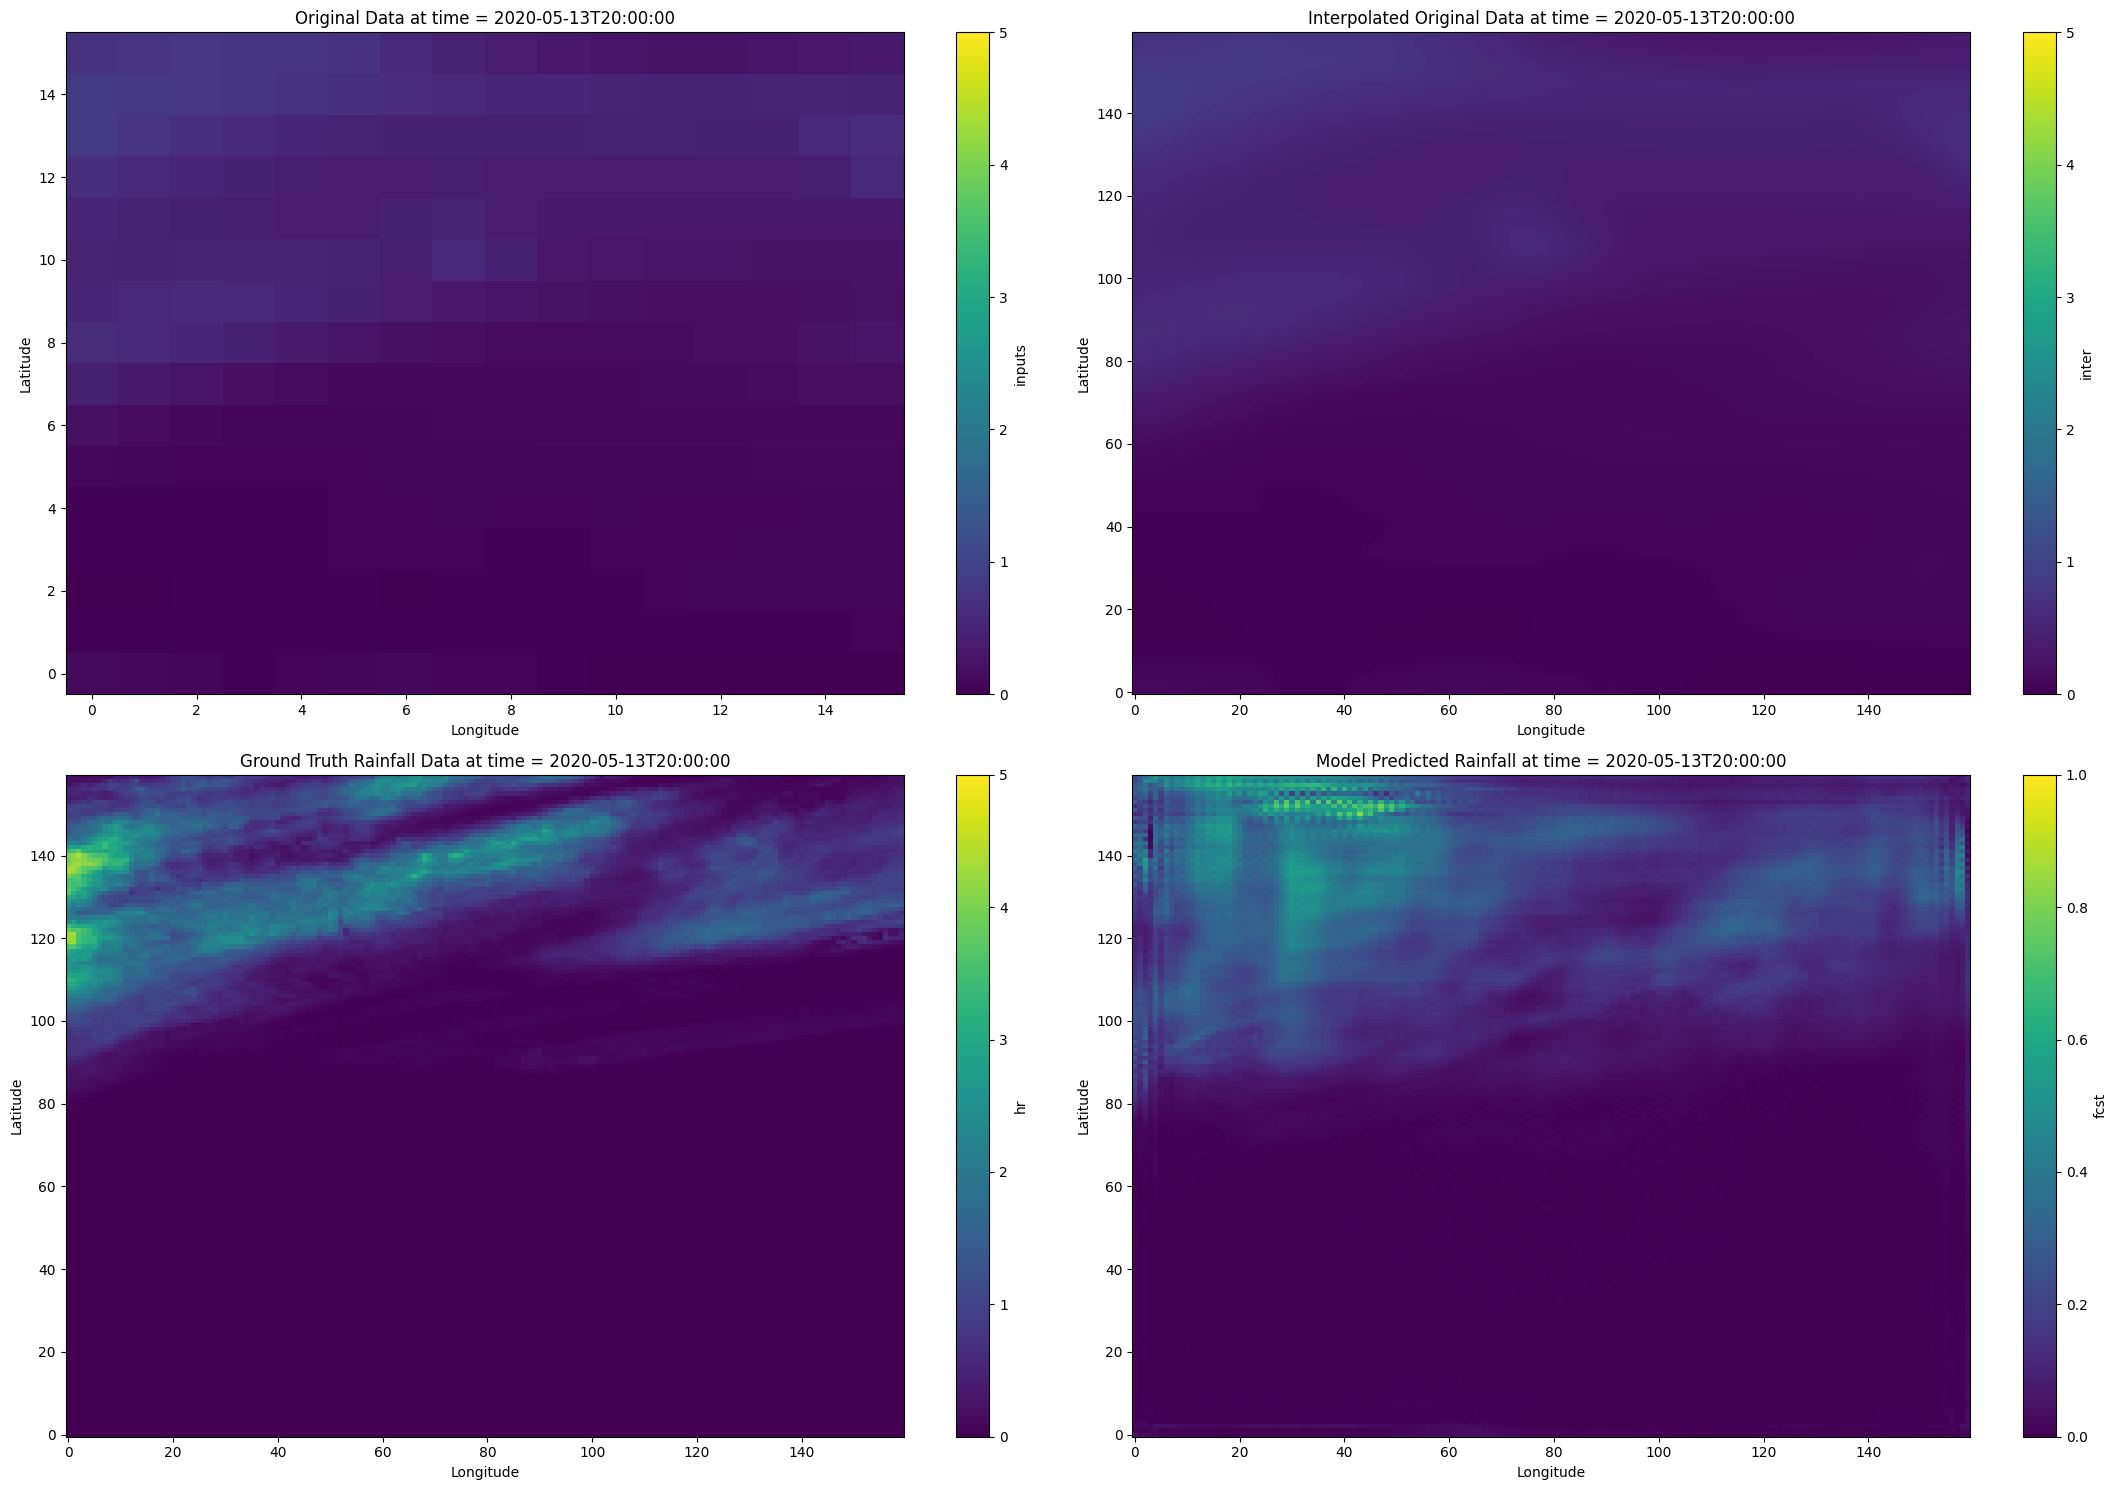

In [20]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# 加载数据集
dn = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_7_onestep_l1_nofc_aheadtop_05_addprecipnorm/prcp_downs_unet_year_2020.nc")
time_index = 3080 #530 290 610 580 350 6200 5000     #650 380 3600 4500 30 60 460 920 1660 2420 2780 2940 3020 3080 3920 5190 5410 2940 650
time = pd.to_datetime(dn["time"].values[time_index]).isoformat()

# 创建两行两列的图布局
fig, axes = plt.subplots(2, 2, figsize=(22,15))

# 第一个图：原始数据
dn["inputs"].isel(time=time_index).plot(ax=axes[0, 0], vmin=0, vmax=5)
axes[0, 0].set_title(f'Original Data at time = {time}')
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')

# 第二个图：原始数据的插值
dn["inter"].isel(time=time_index).plot(ax=axes[0, 1], vmin=0, vmax=5)
axes[0, 1].set_title(f'Interpolated Original Data at time = {time}')
axes[0, 1].set_xlabel('Longitude')
axes[0, 1].set_ylabel('Latitude')

# 第三个图：真实数据（雷达）
dn["hr"].isel(time=time_index).plot(ax=axes[1, 0], vmin=0, vmax=5)
axes[1, 0].set_title(f'Ground Truth Rainfall Data at time = {time}')
axes[1, 0].set_xlabel('Longitude')
axes[1, 0].set_ylabel('Latitude')

# 第四个图：模型预测的降水数据
dn["fcst"].isel(time=time_index).plot(ax=axes[1, 1], vmin=0, vmax=1)
axes[1, 1].set_title(f'Model Predicted Rainfall at time = {time}')
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()


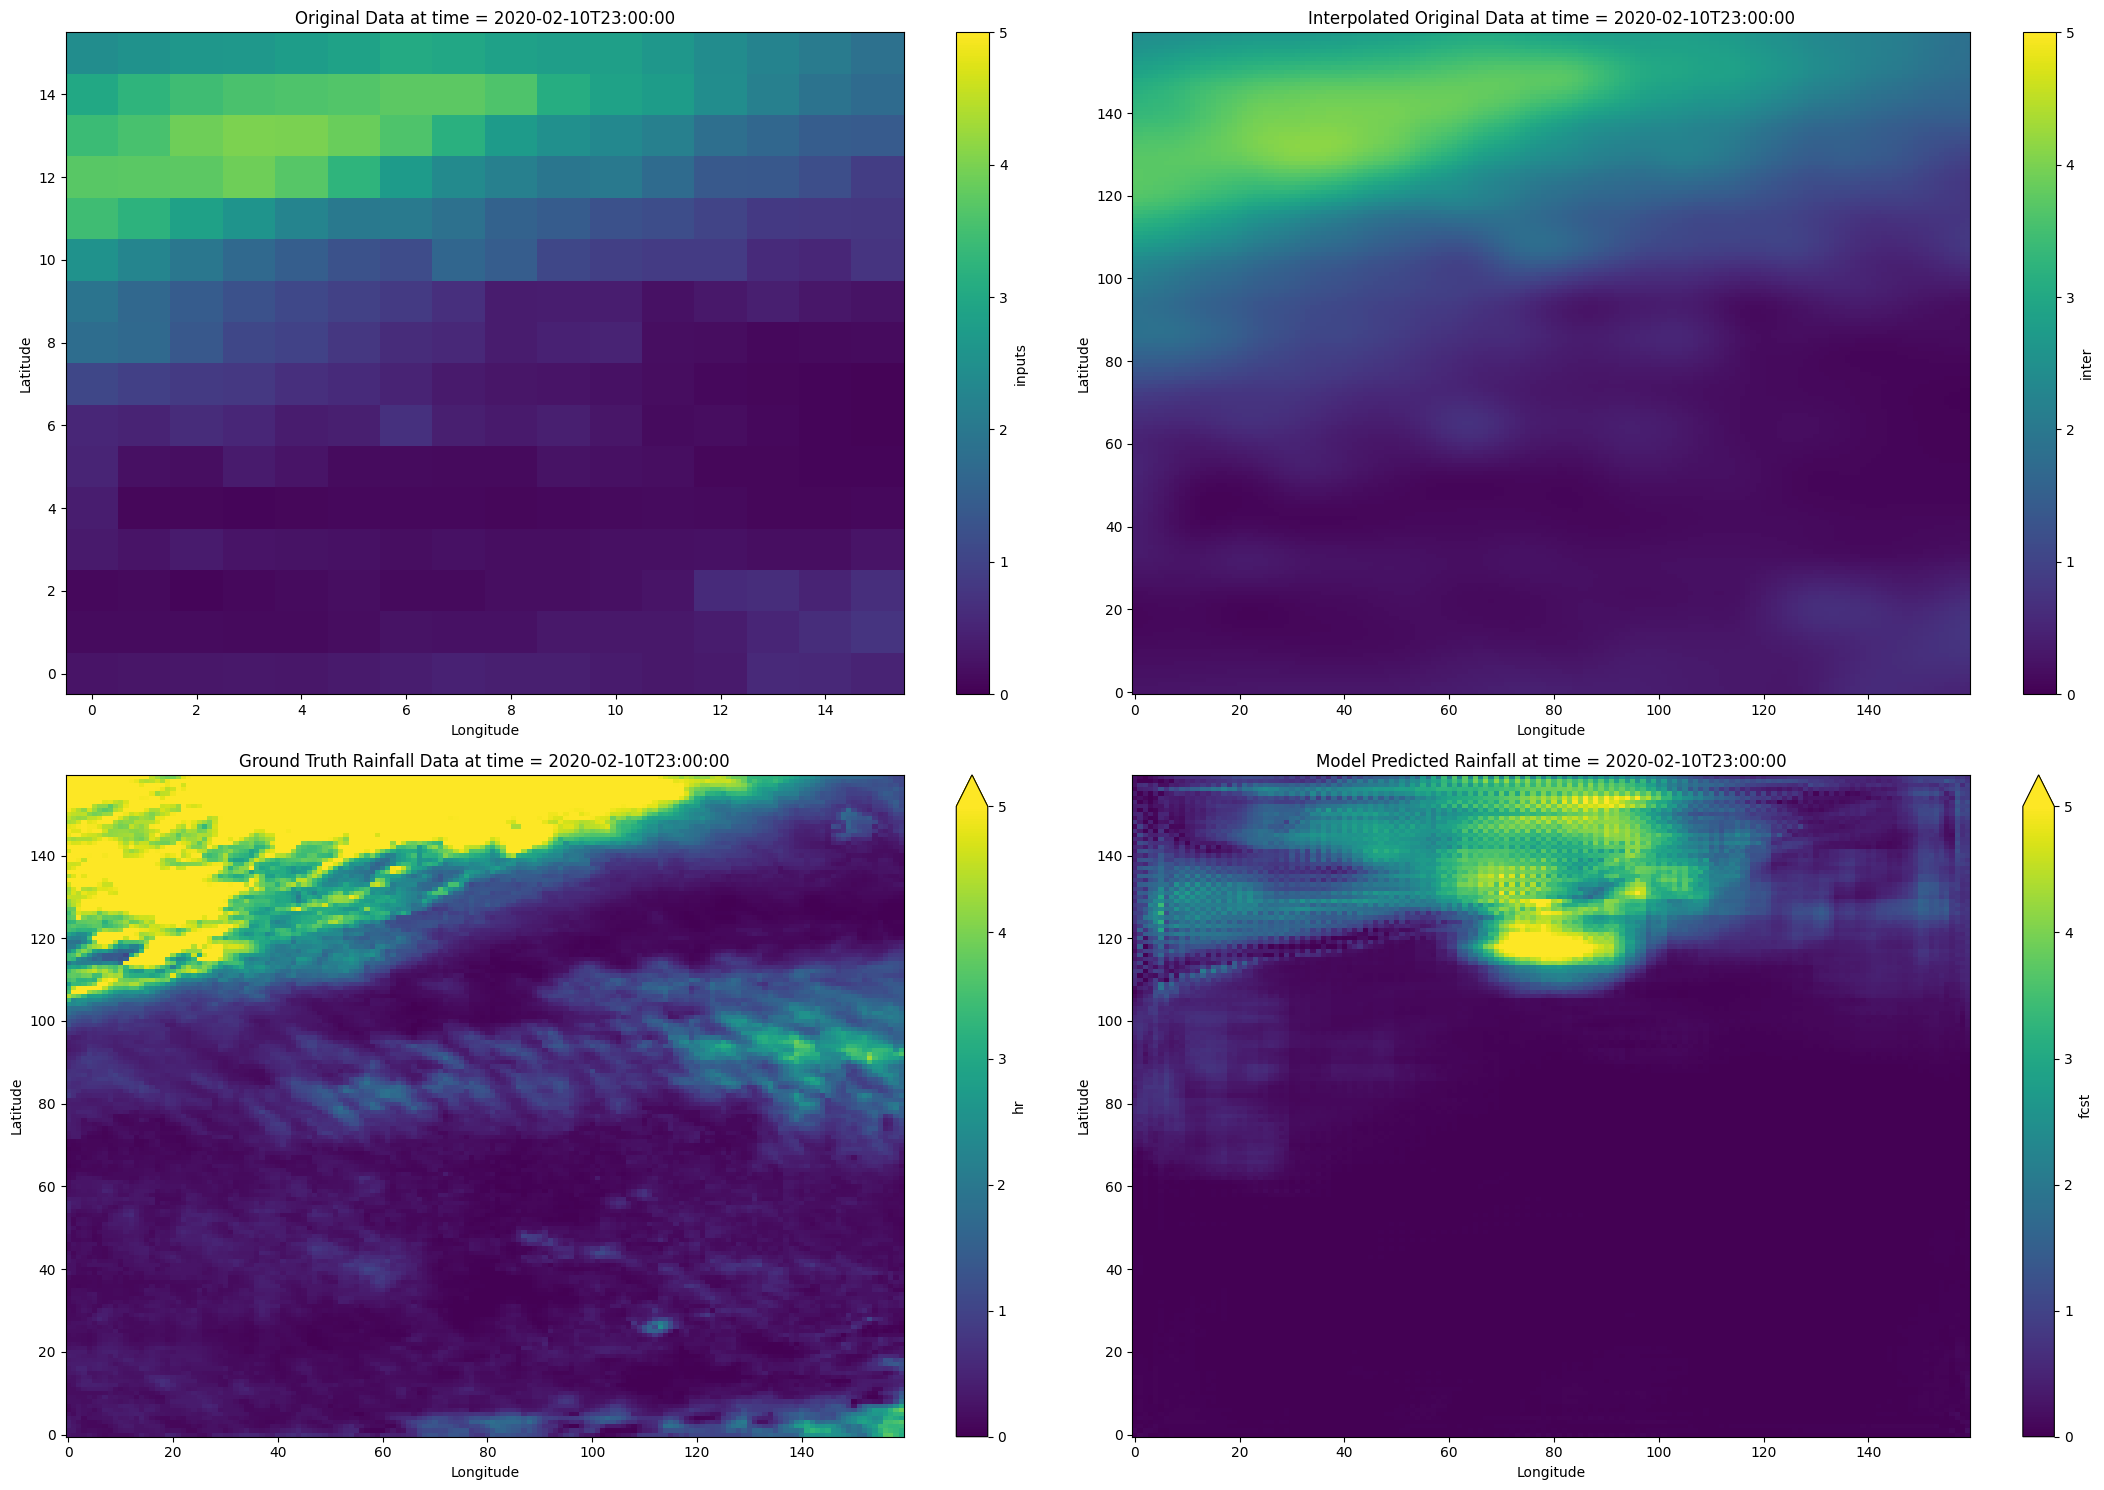

In [2]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# 加载数据集
dn = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_5_onestep_l1_nofc_aheadtop_5_addprecipnorm/prcp_downs_unet_year_2020.nc")
time_index = 652 #530 290 610 580 350 6200 5000     #650 380 3600 4500 30 60 460 920 1660 2420 2780 2940 3020 3080 3920 5190 5410 2940 650
time = pd.to_datetime(dn["time"].values[time_index]).isoformat()

# 创建两行两列的图布局
fig, axes = plt.subplots(2, 2, figsize=(22,15))

# 第一个图：原始数据
dn["inputs"].isel(time=time_index).plot(ax=axes[0, 0], vmin=0, vmax=5)
axes[0, 0].set_title(f'Original Data at time = {time}')
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')

# 第二个图：原始数据的插值
dn["inter"].isel(time=time_index).plot(ax=axes[0, 1], vmin=0, vmax=5)
axes[0, 1].set_title(f'Interpolated Original Data at time = {time}')
axes[0, 1].set_xlabel('Longitude')
axes[0, 1].set_ylabel('Latitude')

# 第三个图：真实数据（雷达）
dn["hr"].isel(time=time_index).plot(ax=axes[1, 0], vmin=0, vmax=5)
axes[1, 0].set_title(f'Ground Truth Rainfall Data at time = {time}')
axes[1, 0].set_xlabel('Longitude')
axes[1, 0].set_ylabel('Latitude')

# 第四个图：模型预测的降水数据
dn["fcst"].isel(time=time_index).plot(ax=axes[1, 1], vmin=0, vmax=5)
axes[1, 1].set_title(f'Model Predicted Rainfall at time = {time}')
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()


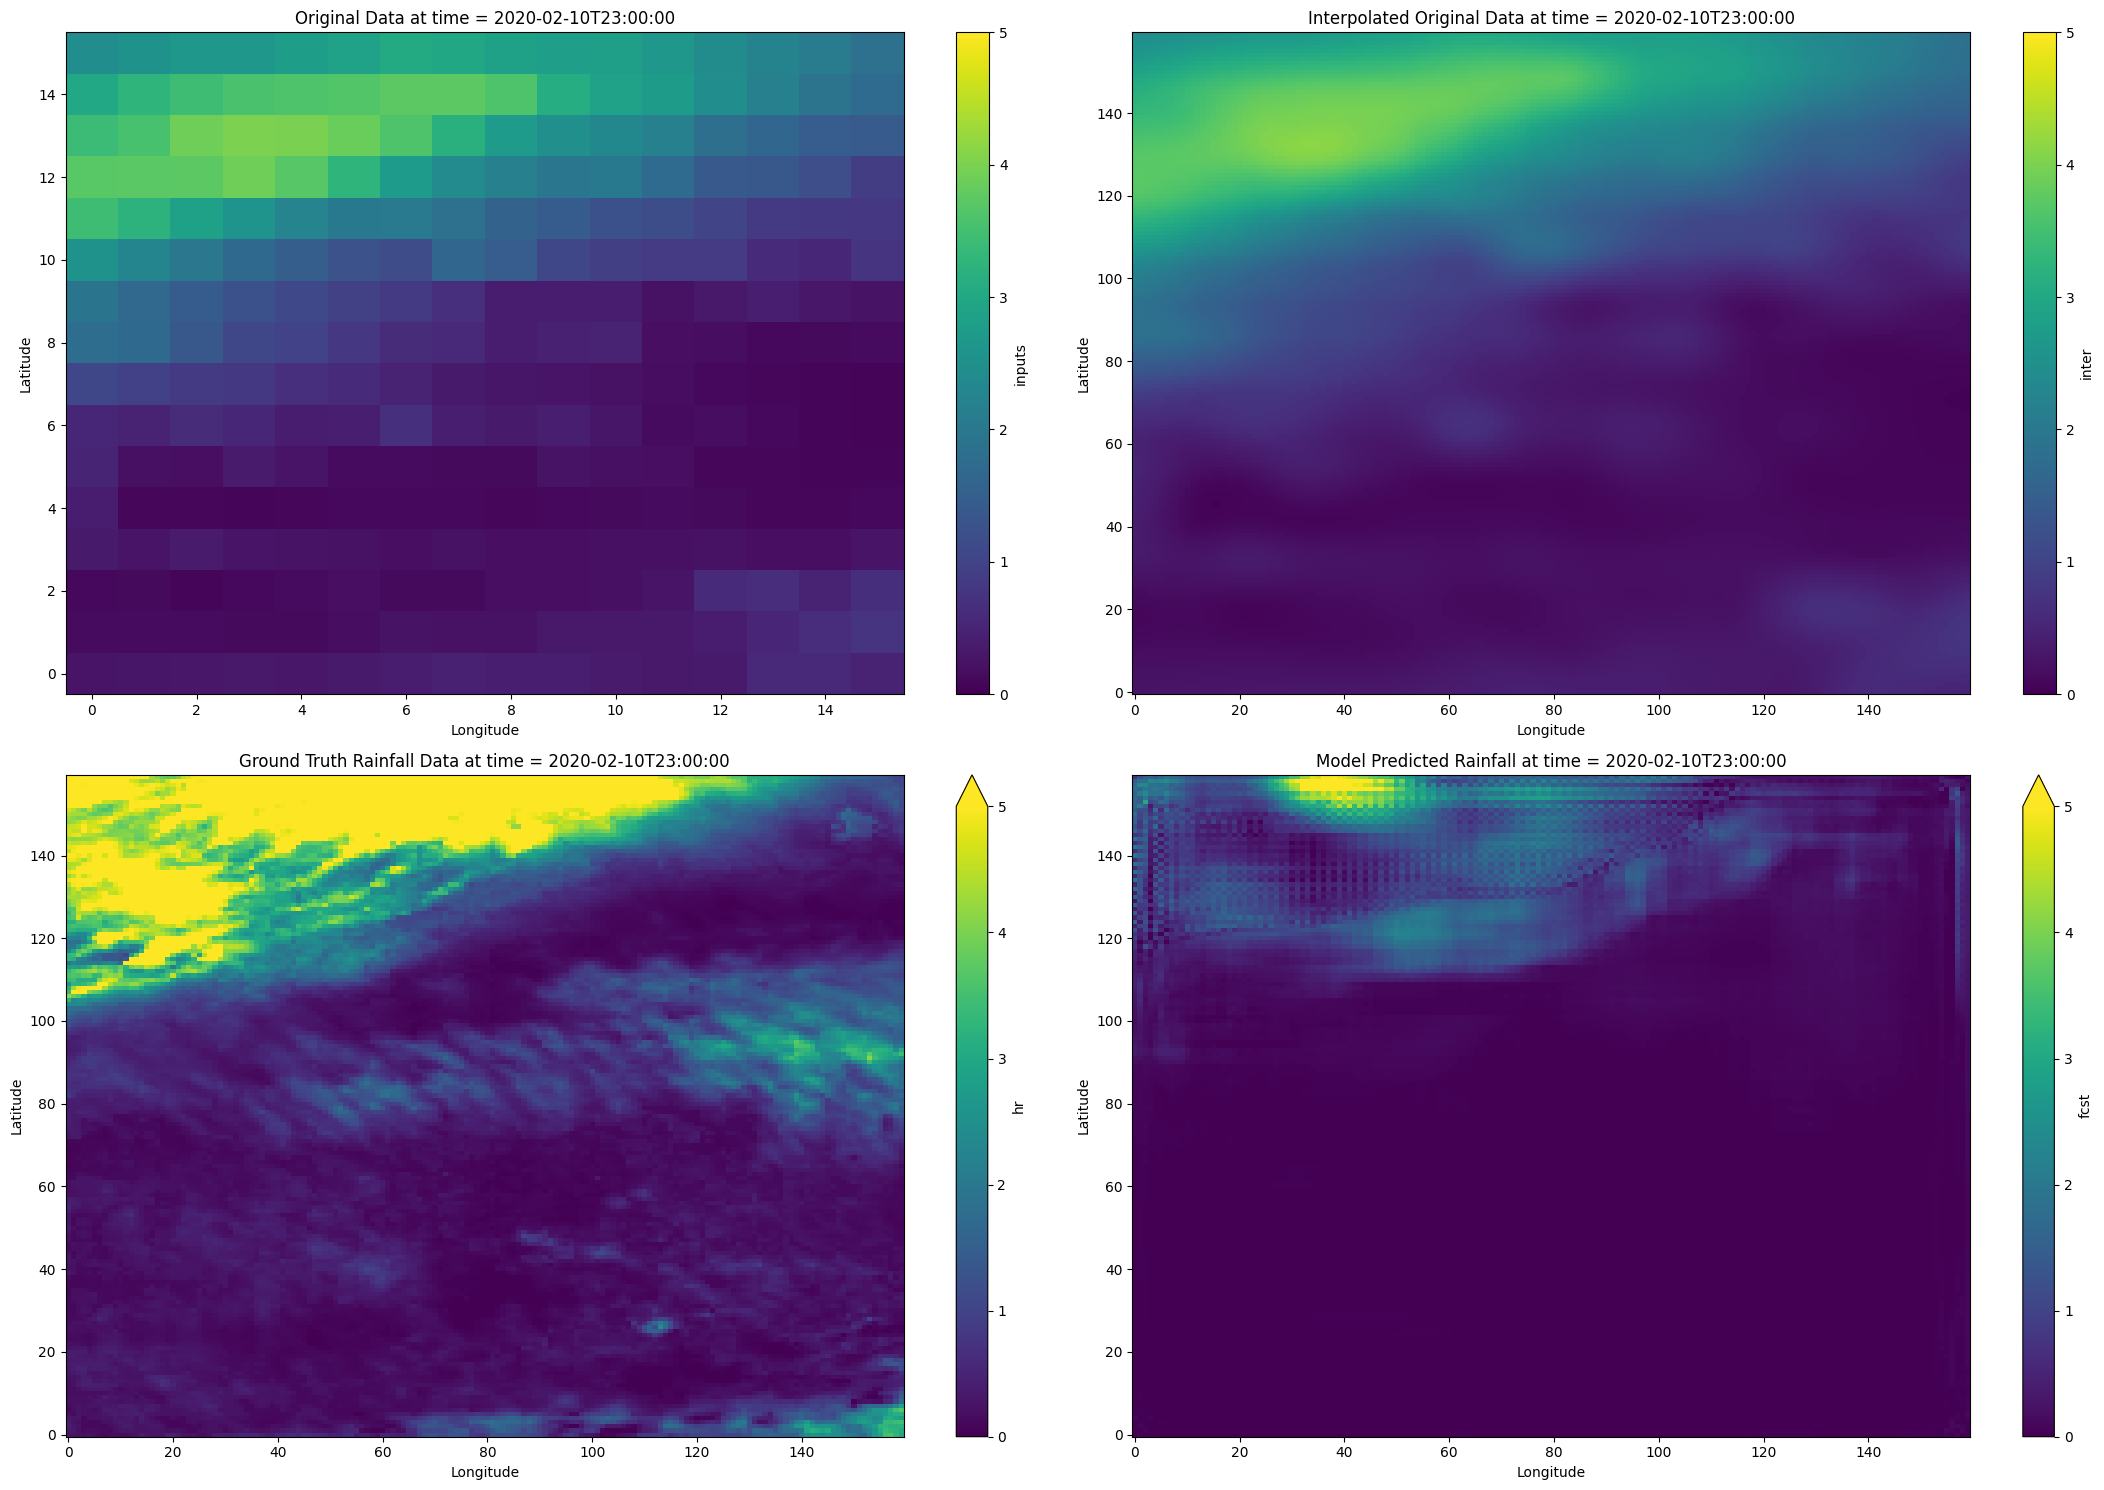

In [1]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# 加载数据集
dn = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_6_onestep_l1_nofc_aheadtop_10_addprecipnorm/prcp_downs_unet_year_2020.nc")
time_index = 652 #530 290 610 580 350 6200 5000     #650 380 3600 4500 30 60 460 920 1660 2420 2780 2940 3020 3080 3920 5190 5410 2940 650
time = pd.to_datetime(dn["time"].values[time_index]).isoformat()

# 创建两行两列的图布局
fig, axes = plt.subplots(2, 2, figsize=(22,15))

# 第一个图：原始数据
dn["inputs"].isel(time=time_index).plot(ax=axes[0, 0], vmin=0, vmax=5)
axes[0, 0].set_title(f'Original Data at time = {time}')
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')

# 第二个图：原始数据的插值
dn["inter"].isel(time=time_index).plot(ax=axes[0, 1], vmin=0, vmax=5)
axes[0, 1].set_title(f'Interpolated Original Data at time = {time}')
axes[0, 1].set_xlabel('Longitude')
axes[0, 1].set_ylabel('Latitude')

# 第三个图：真实数据（雷达）
dn["hr"].isel(time=time_index).plot(ax=axes[1, 0], vmin=0, vmax=5)
axes[1, 0].set_title(f'Ground Truth Rainfall Data at time = {time}')
axes[1, 0].set_xlabel('Longitude')
axes[1, 0].set_ylabel('Latitude')

# 第四个图：模型预测的降水数据
dn["fcst"].isel(time=time_index).plot(ax=axes[1, 1], vmin=0, vmax=5)
axes[1, 1].set_title(f'Model Predicted Rainfall at time = {time}')
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()


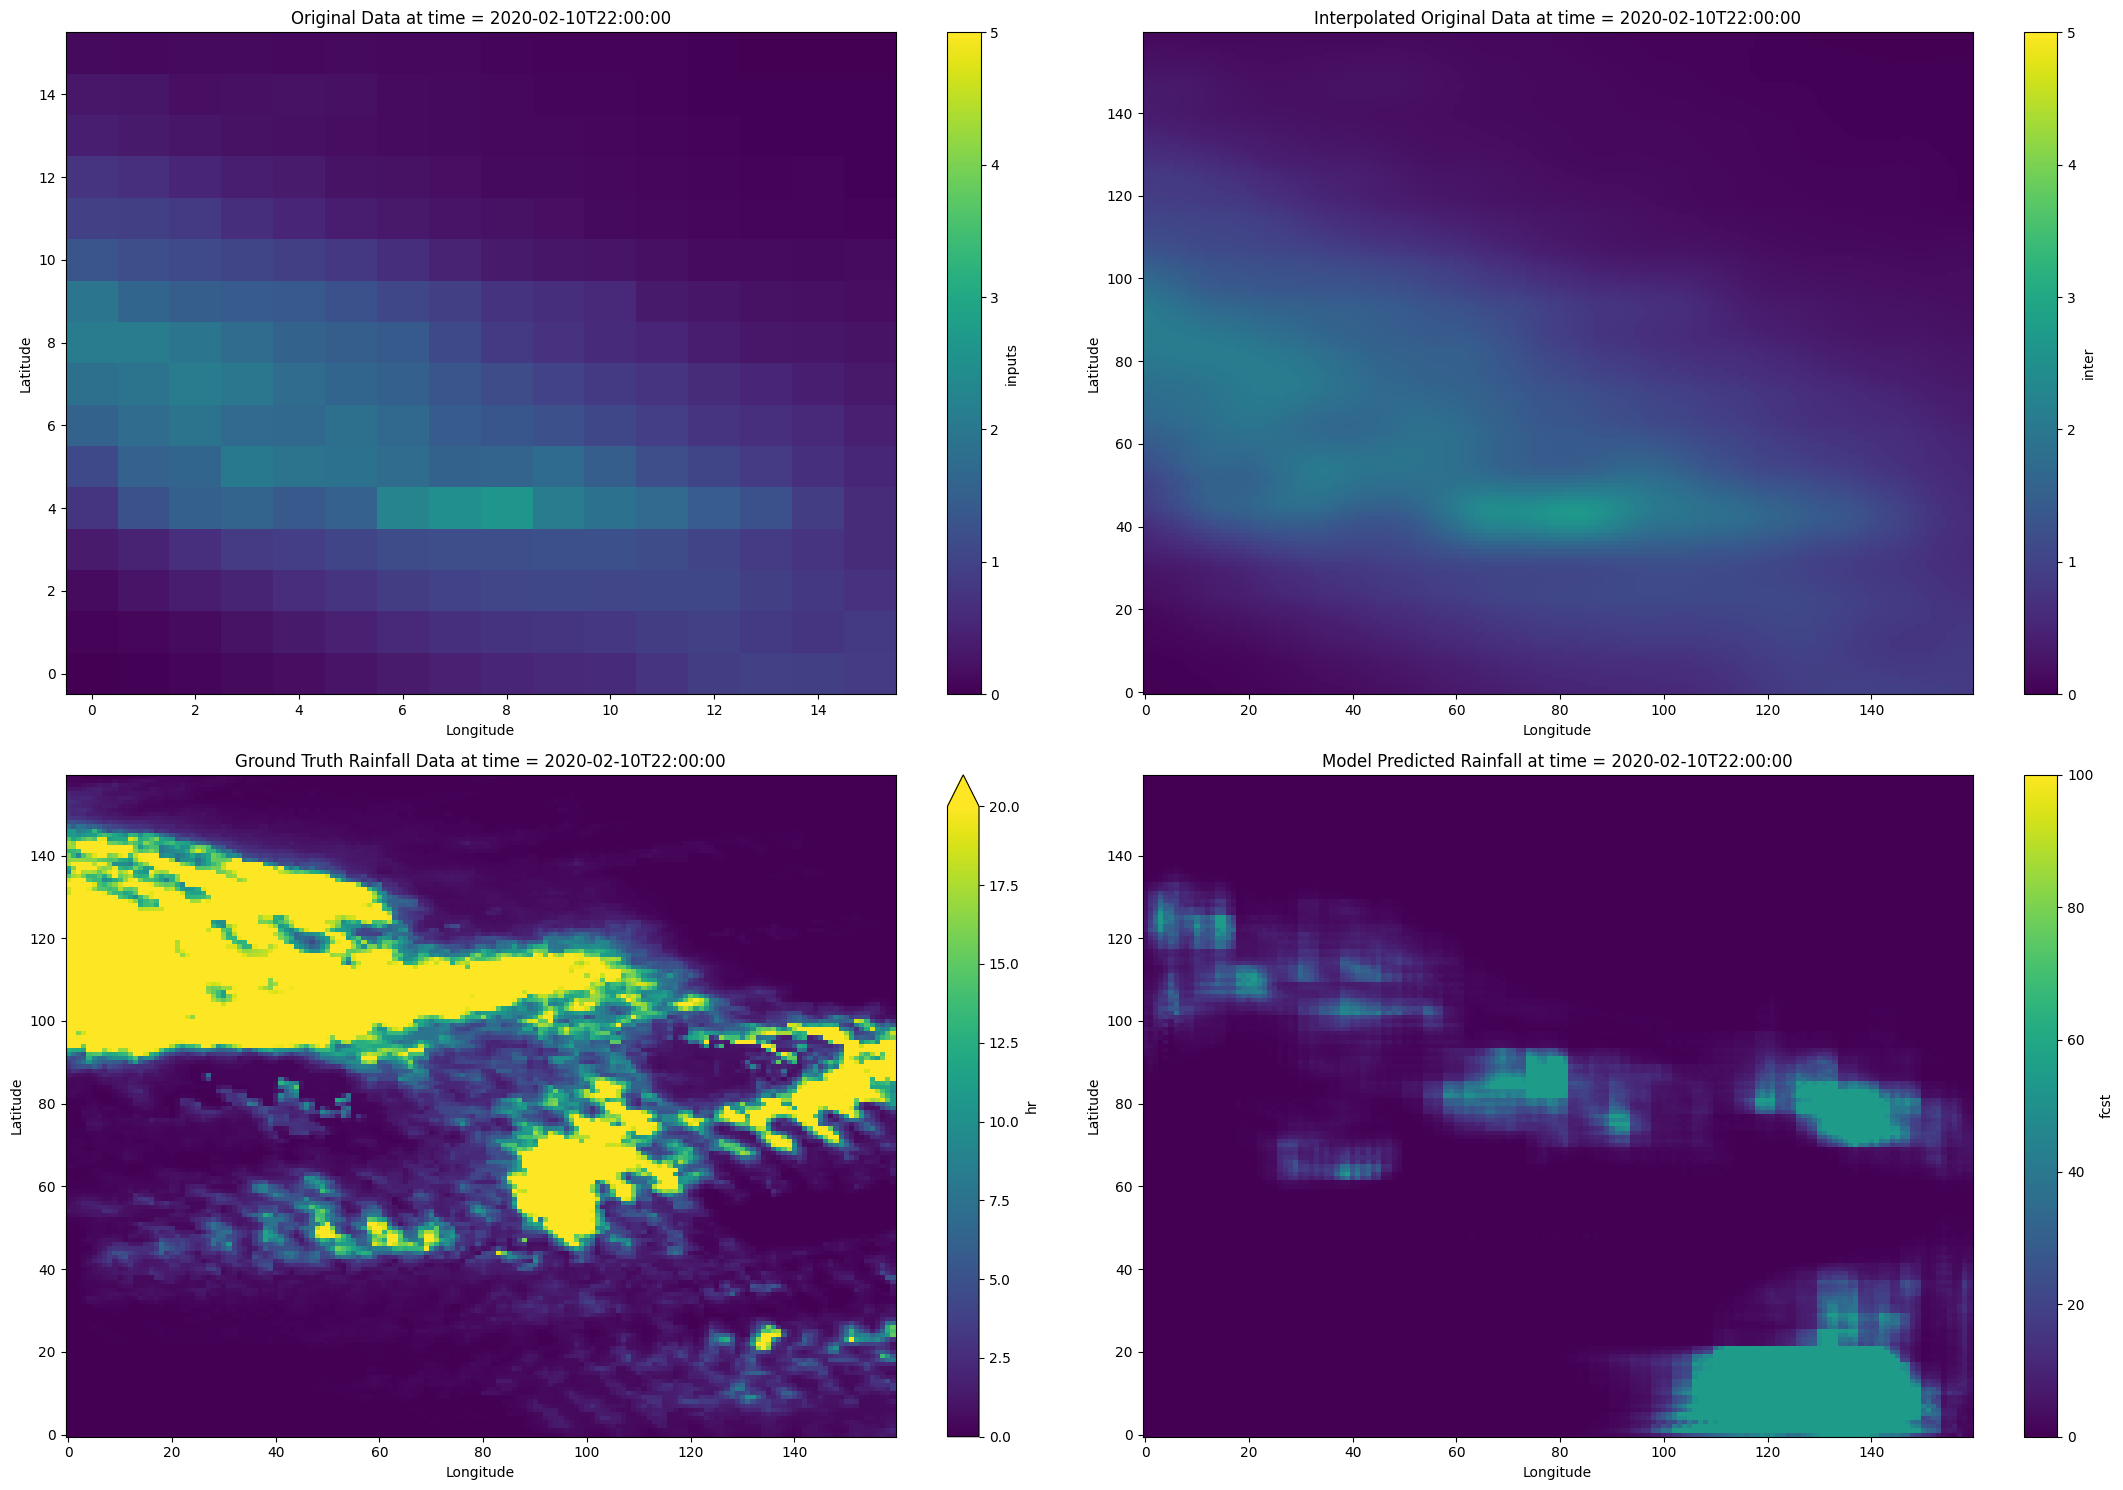

In [6]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# 加载数据集
dn = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_7_onestep_l1_nofc_aheadtop_05_addprecipnorm/prcp_downs_unet_year_2020.nc")
time_index = 650 #530 290 610 580 350 6200 5000     #650 380 3600 4500 30 60 460 920 1660 2420 2780 2940 3020 3080 3920 5190 5410 2940 650
time = pd.to_datetime(dn["time"].values[time_index]).isoformat()

# 创建两行两列的图布局
fig, axes = plt.subplots(2, 2, figsize=(22,15))

# 第一个图：原始数据
dn["inputs"].isel(time=time_index).plot(ax=axes[0, 0], vmin=0, vmax=5)
axes[0, 0].set_title(f'Original Data at time = {time}')
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')

# 第二个图：原始数据的插值
dn["inter"].isel(time=time_index).plot(ax=axes[0, 1], vmin=0, vmax=5)
axes[0, 1].set_title(f'Interpolated Original Data at time = {time}')
axes[0, 1].set_xlabel('Longitude')
axes[0, 1].set_ylabel('Latitude')

# 第三个图：真实数据（雷达）
dn["hr"].isel(time=time_index).plot(ax=axes[1, 0], vmin=0, vmax=20)
axes[1, 0].set_title(f'Ground Truth Rainfall Data at time = {time}')
axes[1, 0].set_xlabel('Longitude')
axes[1, 0].set_ylabel('Latitude')

# 第四个图：模型预测的降水数据
dn["fcst"].isel(time=time_index).plot(ax=axes[1, 1], vmin=0, vmax=100)
axes[1, 1].set_title(f'Model Predicted Rainfall at time = {time}')
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()


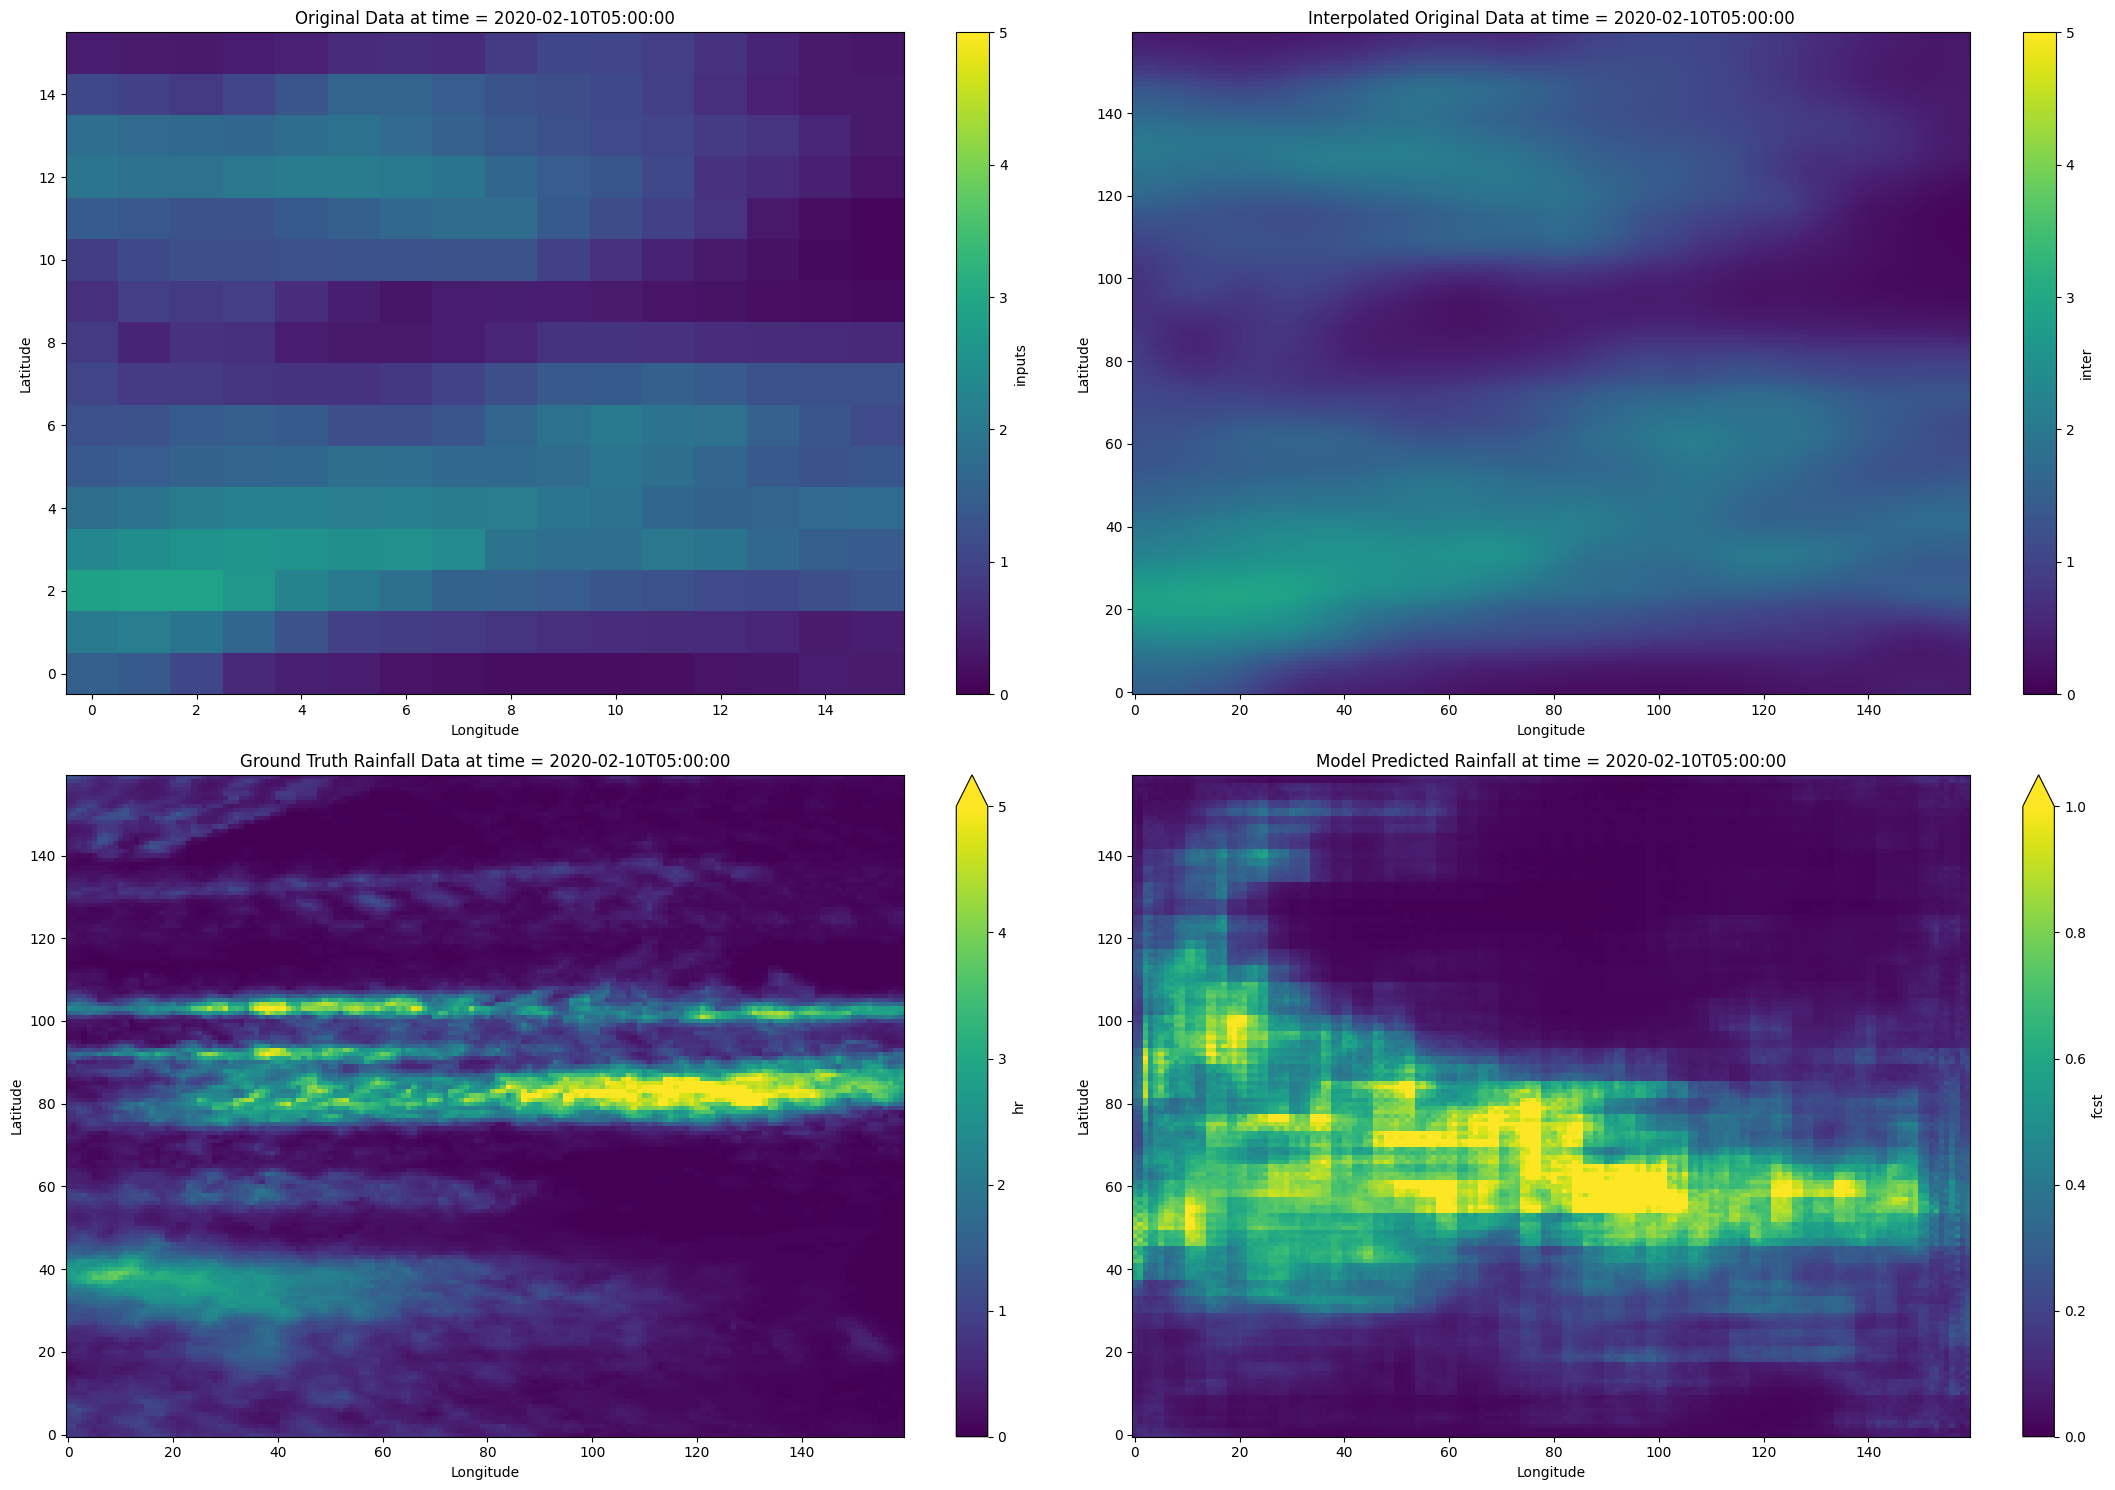

In [6]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# 加载数据集
dn = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_onestep_l2_nofc_aheadtop_0.008/prcp_downs_unet_year_2020.nc")
time_index = 530 #530 290 610 580 350 6200 5000     #650 380 3600 4500 30 60 460 920 1660 2420 2780 2940 3020 3080 3920 5190 5410 2940 650
time = pd.to_datetime(dn["time"].values[time_index]).isoformat()

# 创建两行两列的图布局
fig, axes = plt.subplots(2, 2, figsize=(22,15))

# 第一个图：原始数据
dn["inputs"].isel(time=time_index).plot(ax=axes[0, 0], vmin=0, vmax=5)
axes[0, 0].set_title(f'Original Data at time = {time}')
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')

# 第二个图：原始数据的插值
dn["inter"].isel(time=time_index).plot(ax=axes[0, 1], vmin=0, vmax=5)
axes[0, 1].set_title(f'Interpolated Original Data at time = {time}')
axes[0, 1].set_xlabel('Longitude')
axes[0, 1].set_ylabel('Latitude')

# 第三个图：真实数据（雷达）
dn["hr"].isel(time=time_index).plot(ax=axes[1, 0], vmin=0, vmax=5)
axes[1, 0].set_title(f'Ground Truth Rainfall Data at time = {time}')
axes[1, 0].set_xlabel('Longitude')
axes[1, 0].set_ylabel('Latitude')

# 第四个图：模型预测的降水数据
dn["fcst"].isel(time=time_index).plot(ax=axes[1, 1], vmin=0, vmax=1)
axes[1, 1].set_title(f'Model Predicted Rainfall at time = {time}')
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()


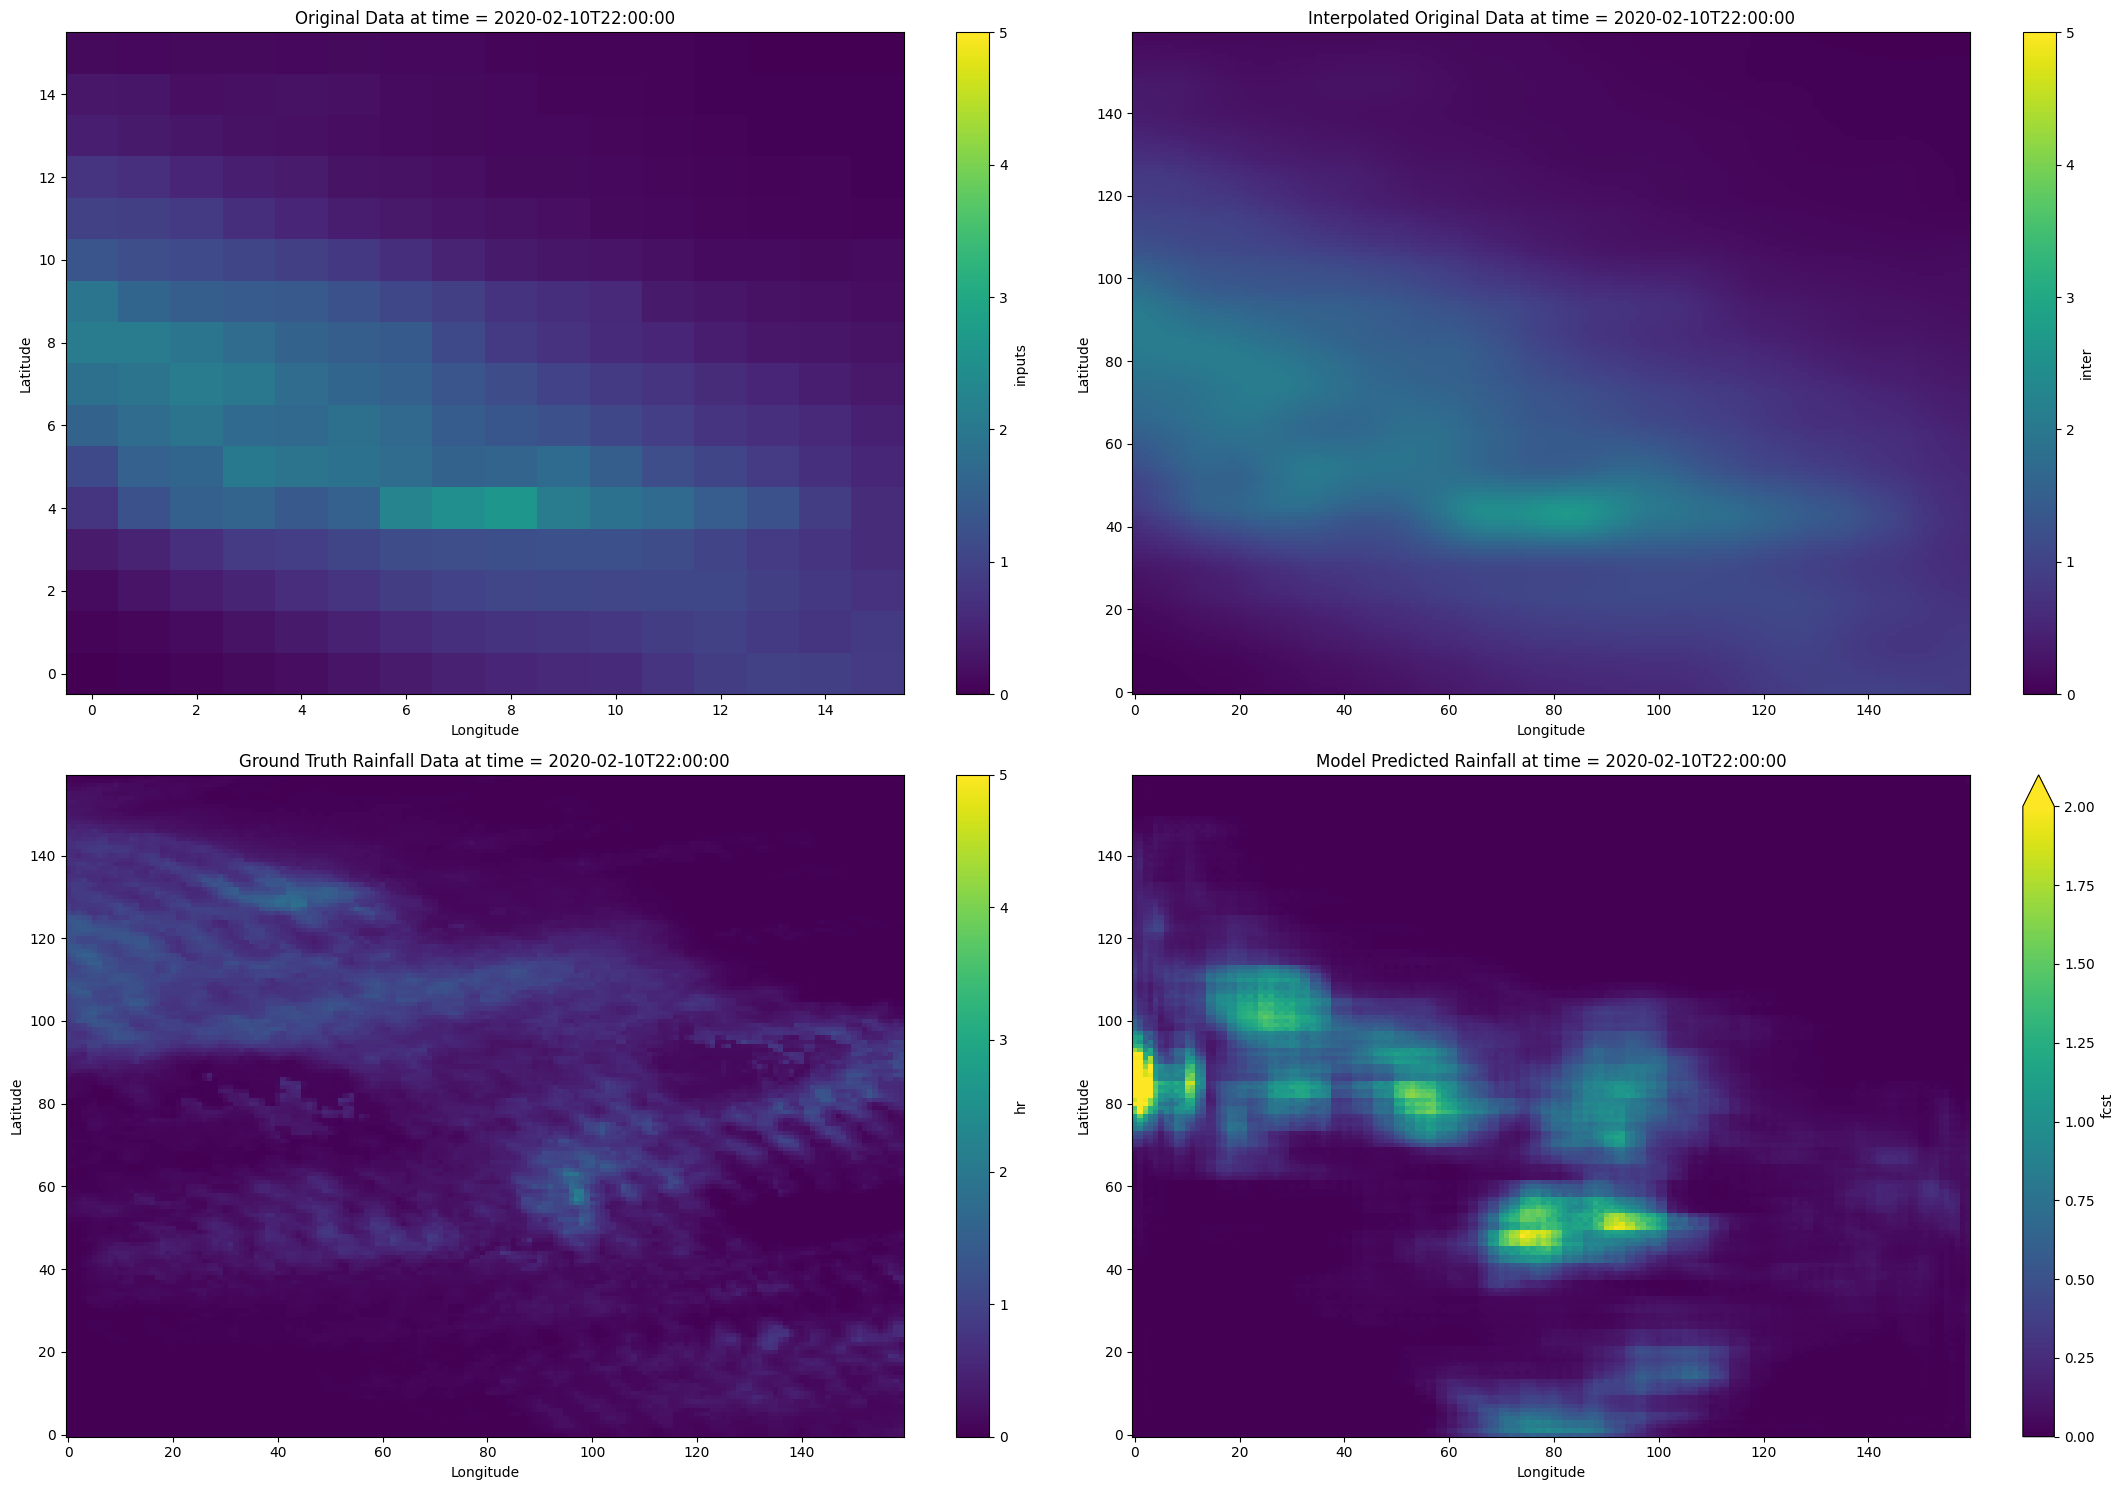

In [2]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# 加载数据集
dn = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_1_onestep_l1_nofc_aheadtop_0.5/prcp_downs_unet_year_2020.nc")
time_index = 650 #530 290 610 580 350 6200 5000     #650 380 3600 4500 30 60 460 920 1660 2420 2780 2940 3020 3080 3920 5190 5410 2940 650
time = pd.to_datetime(dn["time"].values[time_index]).isoformat()

# 创建两行两列的图布局
fig, axes = plt.subplots(2, 2, figsize=(22,15))

# 第一个图：原始数据
dn["inputs"].isel(time=time_index).plot(ax=axes[0, 0], vmin=0, vmax=5)
axes[0, 0].set_title(f'Original Data at time = {time}')
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')

# 第二个图：原始数据的插值
dn["inter"].isel(time=time_index).plot(ax=axes[0, 1], vmin=0, vmax=5)
axes[0, 1].set_title(f'Interpolated Original Data at time = {time}')
axes[0, 1].set_xlabel('Longitude')
axes[0, 1].set_ylabel('Latitude')

# 第三个图：真实数据（雷达）
dn["hr"].isel(time=time_index).plot(ax=axes[1, 0], vmin=0, vmax=5)
axes[1, 0].set_title(f'Ground Truth Rainfall Data at time = {time}')
axes[1, 0].set_xlabel('Longitude')
axes[1, 0].set_ylabel('Latitude')

# 第四个图：模型预测的降水数据
dn["fcst"].isel(time=time_index).plot(ax=axes[1, 1], vmin=0, vmax=2)
axes[1, 1].set_title(f'Model Predicted Rainfall at time = {time}')
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()


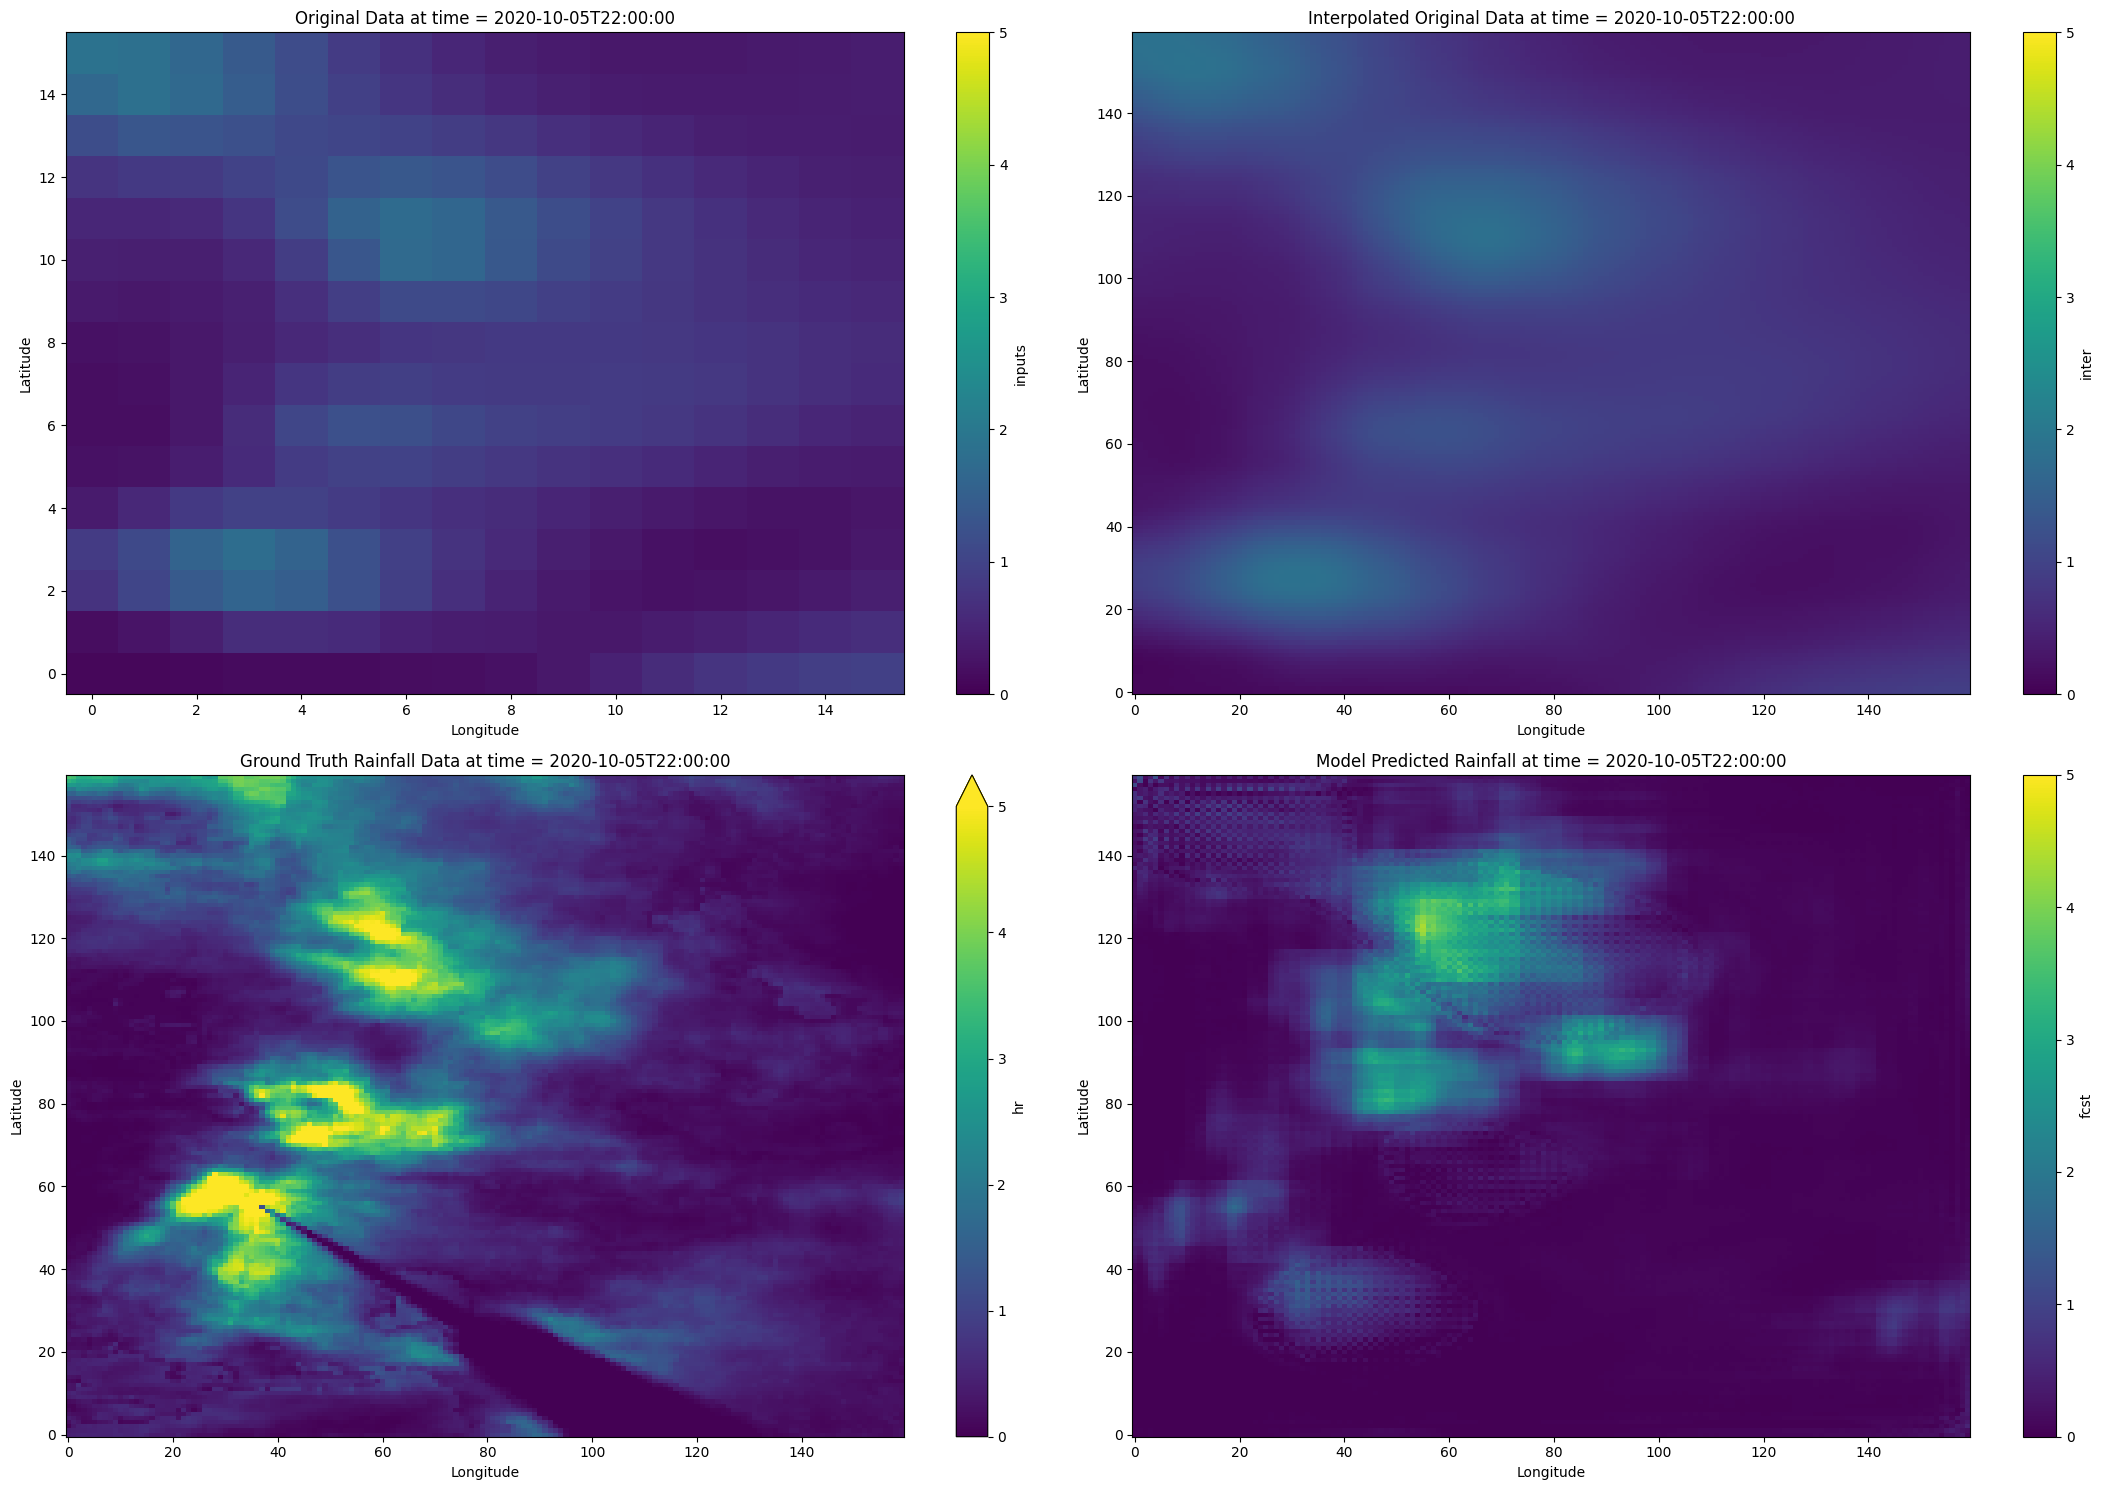

In [14]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# 加载数据集
dn = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_2_onestep_l1_nofc_aheadtop_5/prcp_downs_unet_year_2020.nc")
time_index = 5410 #530 290 610 580 350 6200 5000     #650 380 3600 4500 30 60 460 920 1660 2420 2780 2940 3020 3080 3920 5190 5410 2940 650
time = pd.to_datetime(dn["time"].values[time_index]).isoformat()

# 创建两行两列的图布局
fig, axes = plt.subplots(2, 2, figsize=(22,15))

# 第一个图：原始数据
dn["inputs"].isel(time=time_index).plot(ax=axes[0, 0], vmin=0, vmax=5)
axes[0, 0].set_title(f'Original Data at time = {time}')
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')

# 第二个图：原始数据的插值
dn["inter"].isel(time=time_index).plot(ax=axes[0, 1], vmin=0, vmax=5)
axes[0, 1].set_title(f'Interpolated Original Data at time = {time}')
axes[0, 1].set_xlabel('Longitude')
axes[0, 1].set_ylabel('Latitude')

# 第三个图：真实数据（雷达）
dn["hr"].isel(time=time_index).plot(ax=axes[1, 0], vmin=0, vmax=5)
axes[1, 0].set_title(f'Ground Truth Rainfall Data at time = {time}')
axes[1, 0].set_xlabel('Longitude')
axes[1, 0].set_ylabel('Latitude')

# 第四个图：模型预测的降水数据
dn["fcst"].isel(time=time_index).plot(ax=axes[1, 1], vmin=0, vmax=5)
axes[1, 1].set_title(f'Model Predicted Rainfall at time = {time}')
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()


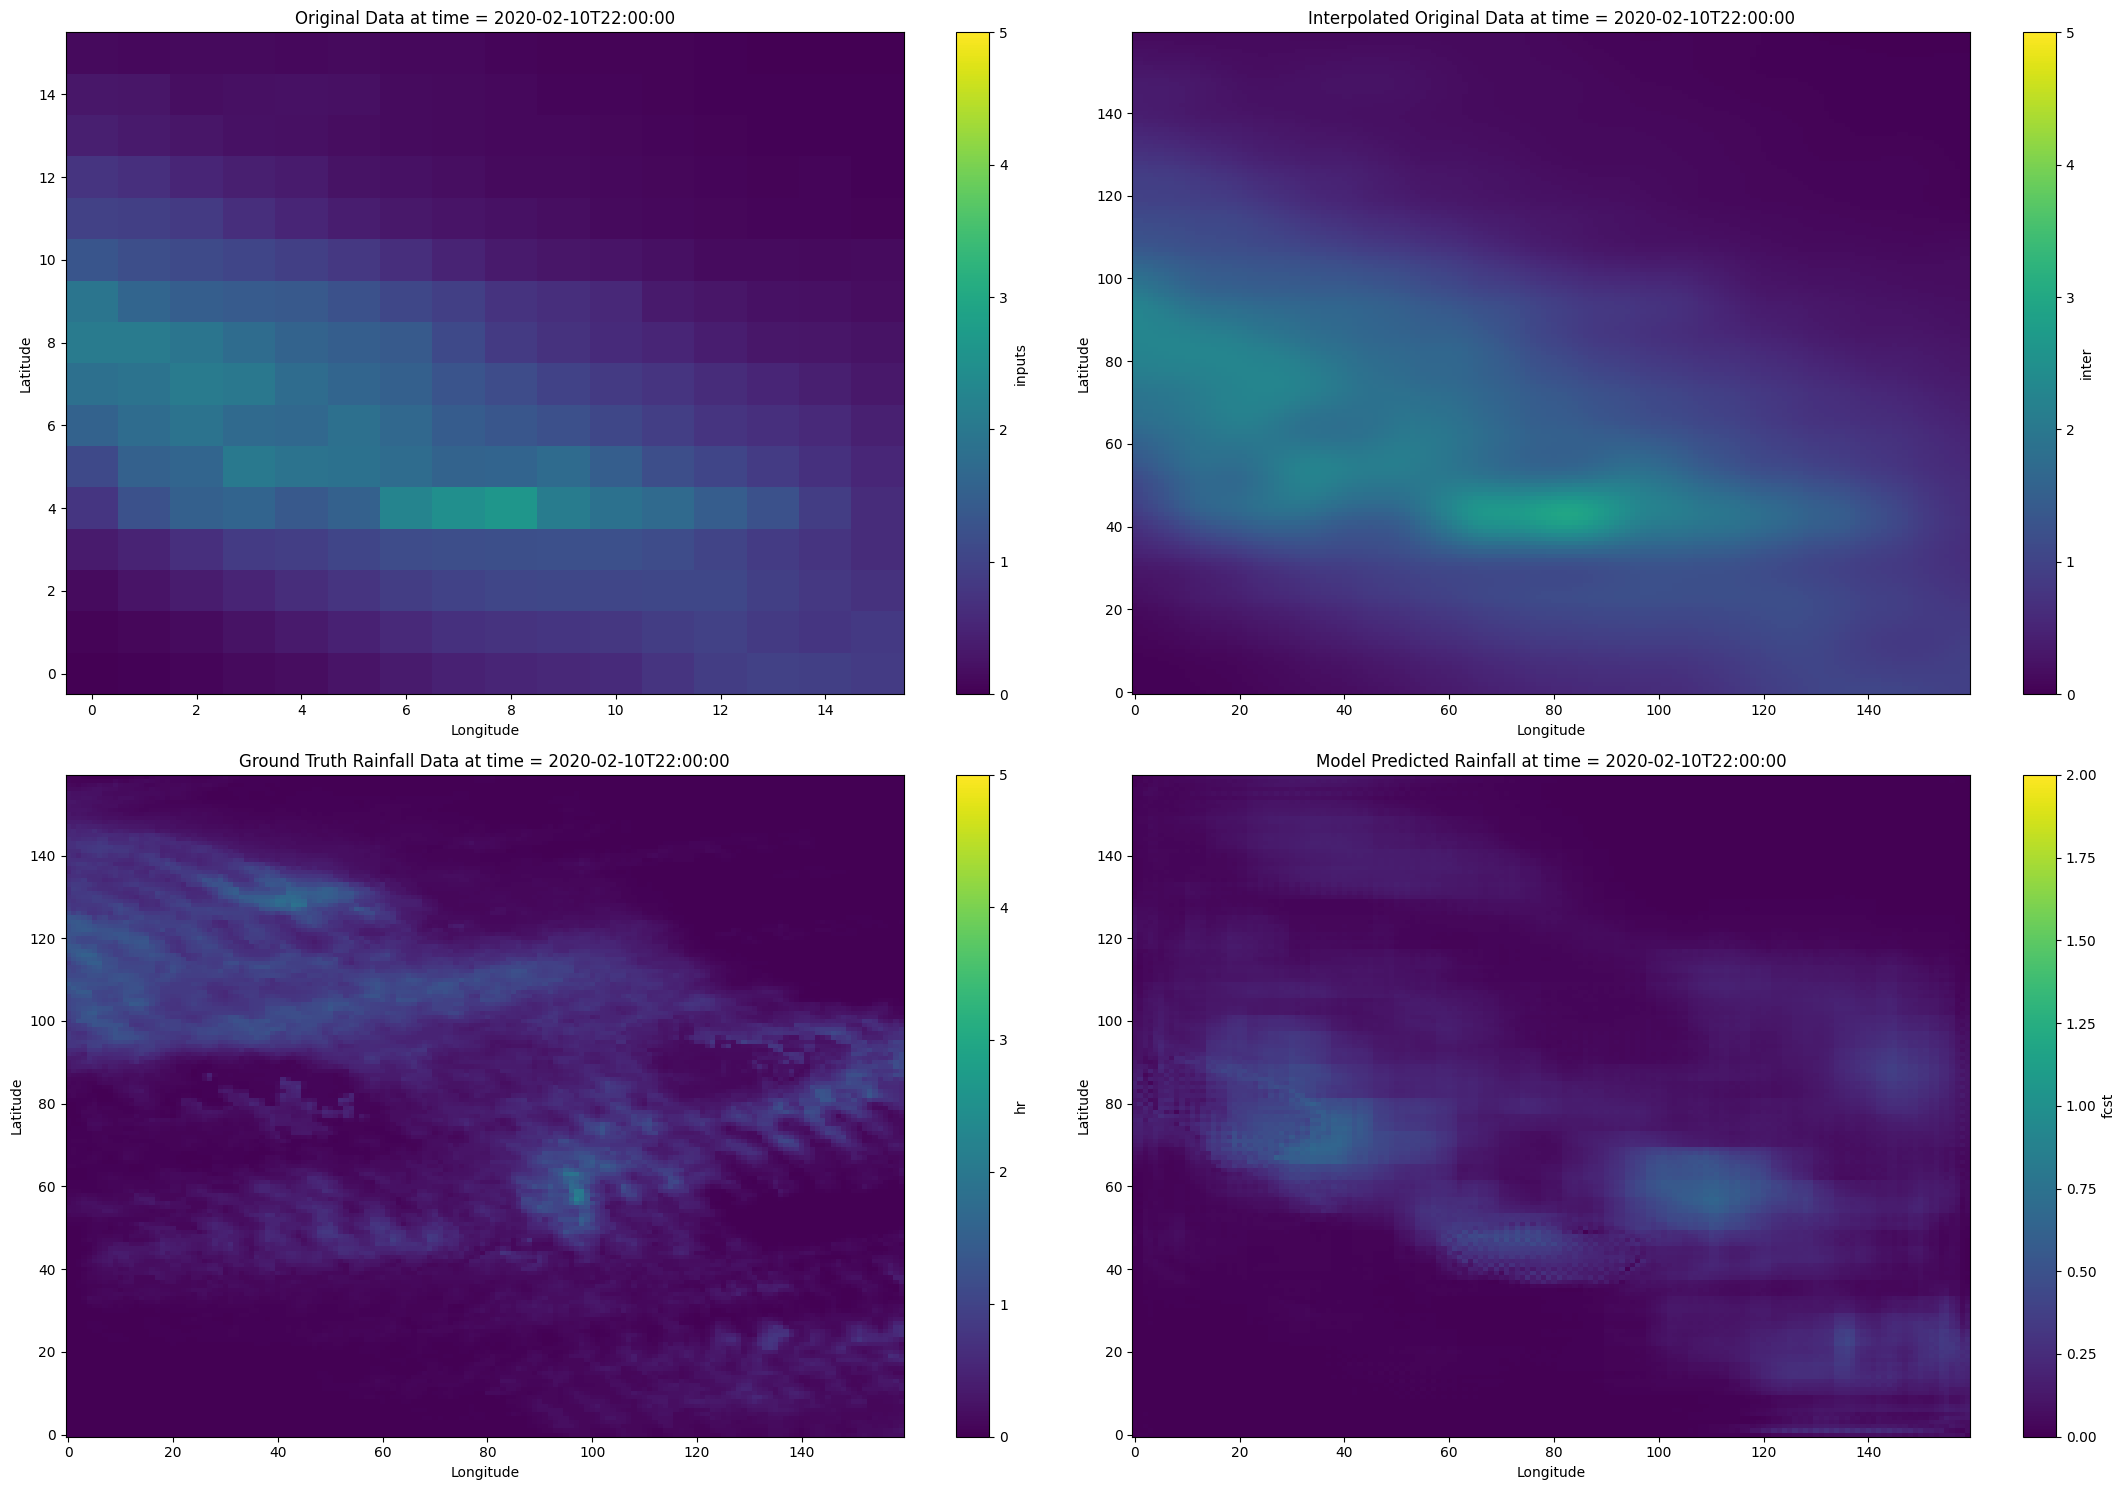

In [3]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# 加载数据集
dn = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_6_onestep_l1_nofc_aheadtop_5_addprecipnorm/prcp_downs_unet_year_2020.nc")
time_index = 650 #530 290 610 580 350 6200 5000     #650 380 3600 4500 30 60 460 920 1660 2420 2780 2940 3020 3080 3920 5190 5410 2940 650
time = pd.to_datetime(dn["time"].values[time_index]).isoformat()

# 创建两行两列的图布局
fig, axes = plt.subplots(2, 2, figsize=(22,15))

# 第一个图：原始数据
dn["inputs"].isel(time=time_index).plot(ax=axes[0, 0], vmin=0, vmax=5)
axes[0, 0].set_title(f'Original Data at time = {time}')
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')

# 第二个图：原始数据的插值
dn["inter"].isel(time=time_index).plot(ax=axes[0, 1], vmin=0, vmax=5)
axes[0, 1].set_title(f'Interpolated Original Data at time = {time}')
axes[0, 1].set_xlabel('Longitude')
axes[0, 1].set_ylabel('Latitude')

# 第三个图：真实数据（雷达）
dn["hr"].isel(time=time_index).plot(ax=axes[1, 0], vmin=0, vmax=5)
axes[1, 0].set_title(f'Ground Truth Rainfall Data at time = {time}')
axes[1, 0].set_xlabel('Longitude')
axes[1, 0].set_ylabel('Latitude')

# 第四个图：模型预测的降水数据
dn["fcst"].isel(time=time_index).plot(ax=axes[1, 1], vmin=0, vmax=2)
axes[1, 1].set_title(f'Model Predicted Rainfall at time = {time}')
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()


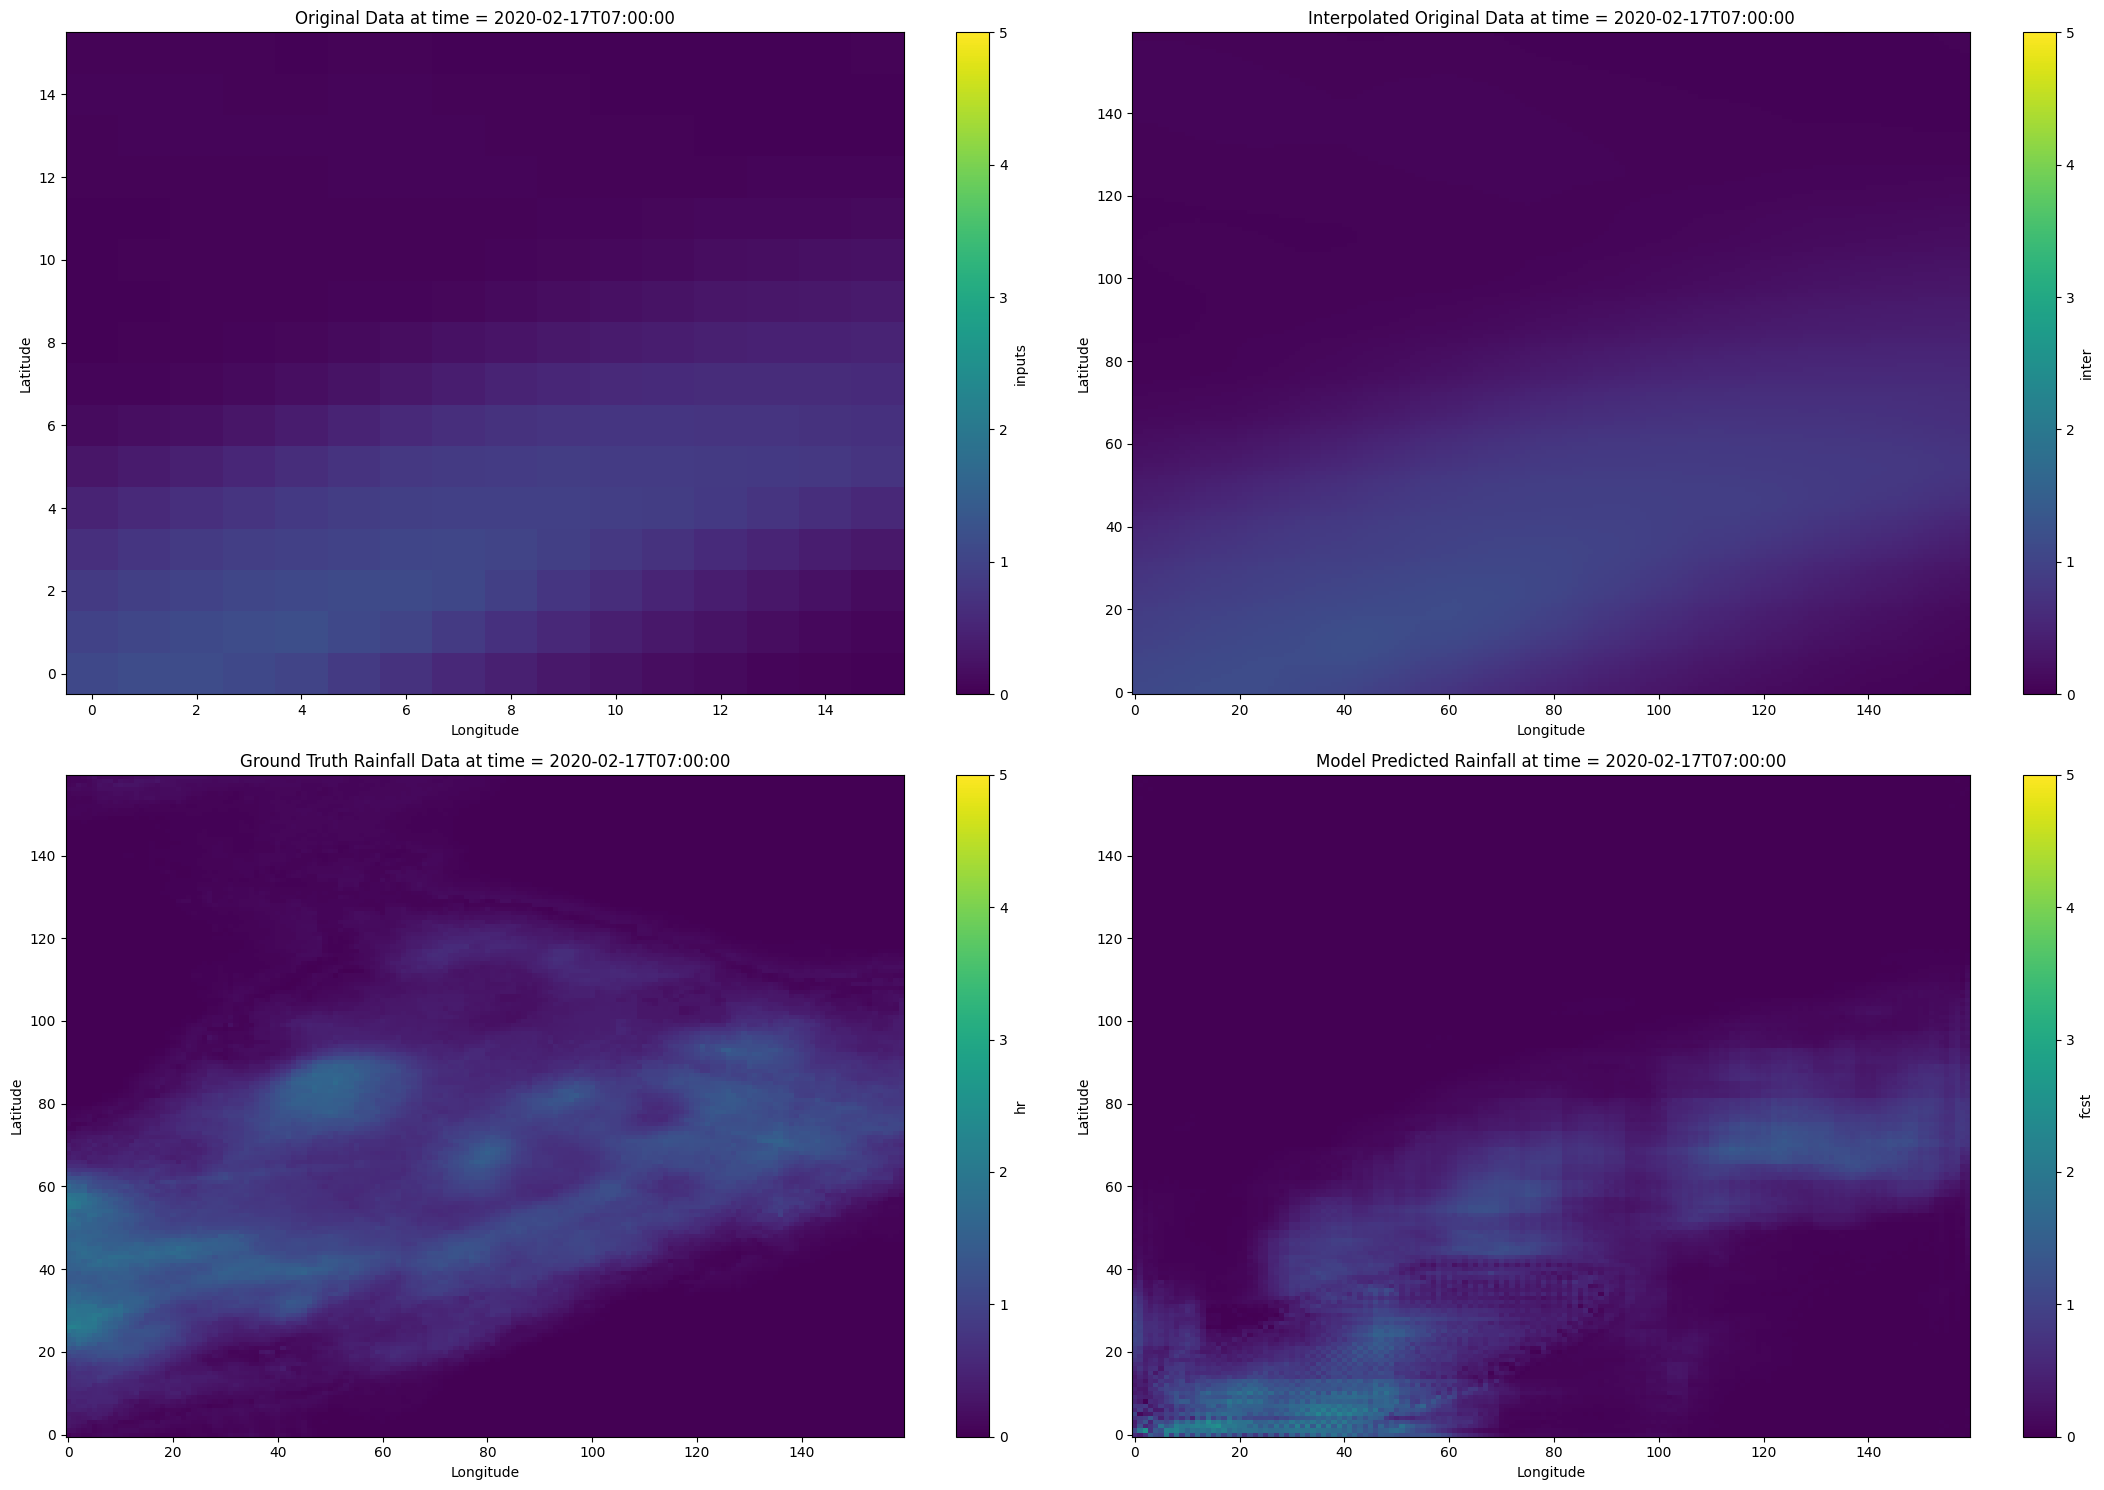

In [27]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# 加载数据集
dn = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_4_onestep_l1_nofc_aheadtop_10/prcp_downs_unet_year_2020.nc")
time_index = 909 #530 290 610 580 350 6200 5000     #650 380 3600 4500 30 60 460 920 1660 2420 2780 2940 3020 3080 3920 5190 5410 2940 650
time = pd.to_datetime(dn["time"].values[time_index]).isoformat()

# 创建两行两列的图布局
fig, axes = plt.subplots(2, 2, figsize=(22,15))

# 第一个图：原始数据
dn["inputs"].isel(time=time_index).plot(ax=axes[0, 0], vmin=0, vmax=5)
axes[0, 0].set_title(f'Original Data at time = {time}')
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')

# 第二个图：原始数据的插值
dn["inter"].isel(time=time_index).plot(ax=axes[0, 1], vmin=0, vmax=5)
axes[0, 1].set_title(f'Interpolated Original Data at time = {time}')
axes[0, 1].set_xlabel('Longitude')
axes[0, 1].set_ylabel('Latitude')

# 第三个图：真实数据（雷达）
dn["hr"].isel(time=time_index).plot(ax=axes[1, 0], vmin=0, vmax=5)
axes[1, 0].set_title(f'Ground Truth Rainfall Data at time = {time}')
axes[1, 0].set_xlabel('Longitude')
axes[1, 0].set_ylabel('Latitude')

# 第四个图：模型预测的降水数据
dn["fcst"].isel(time=time_index).plot(ax=axes[1, 1], vmin=0, vmax=5)
axes[1, 1].set_title(f'Model Predicted Rainfall at time = {time}')
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()


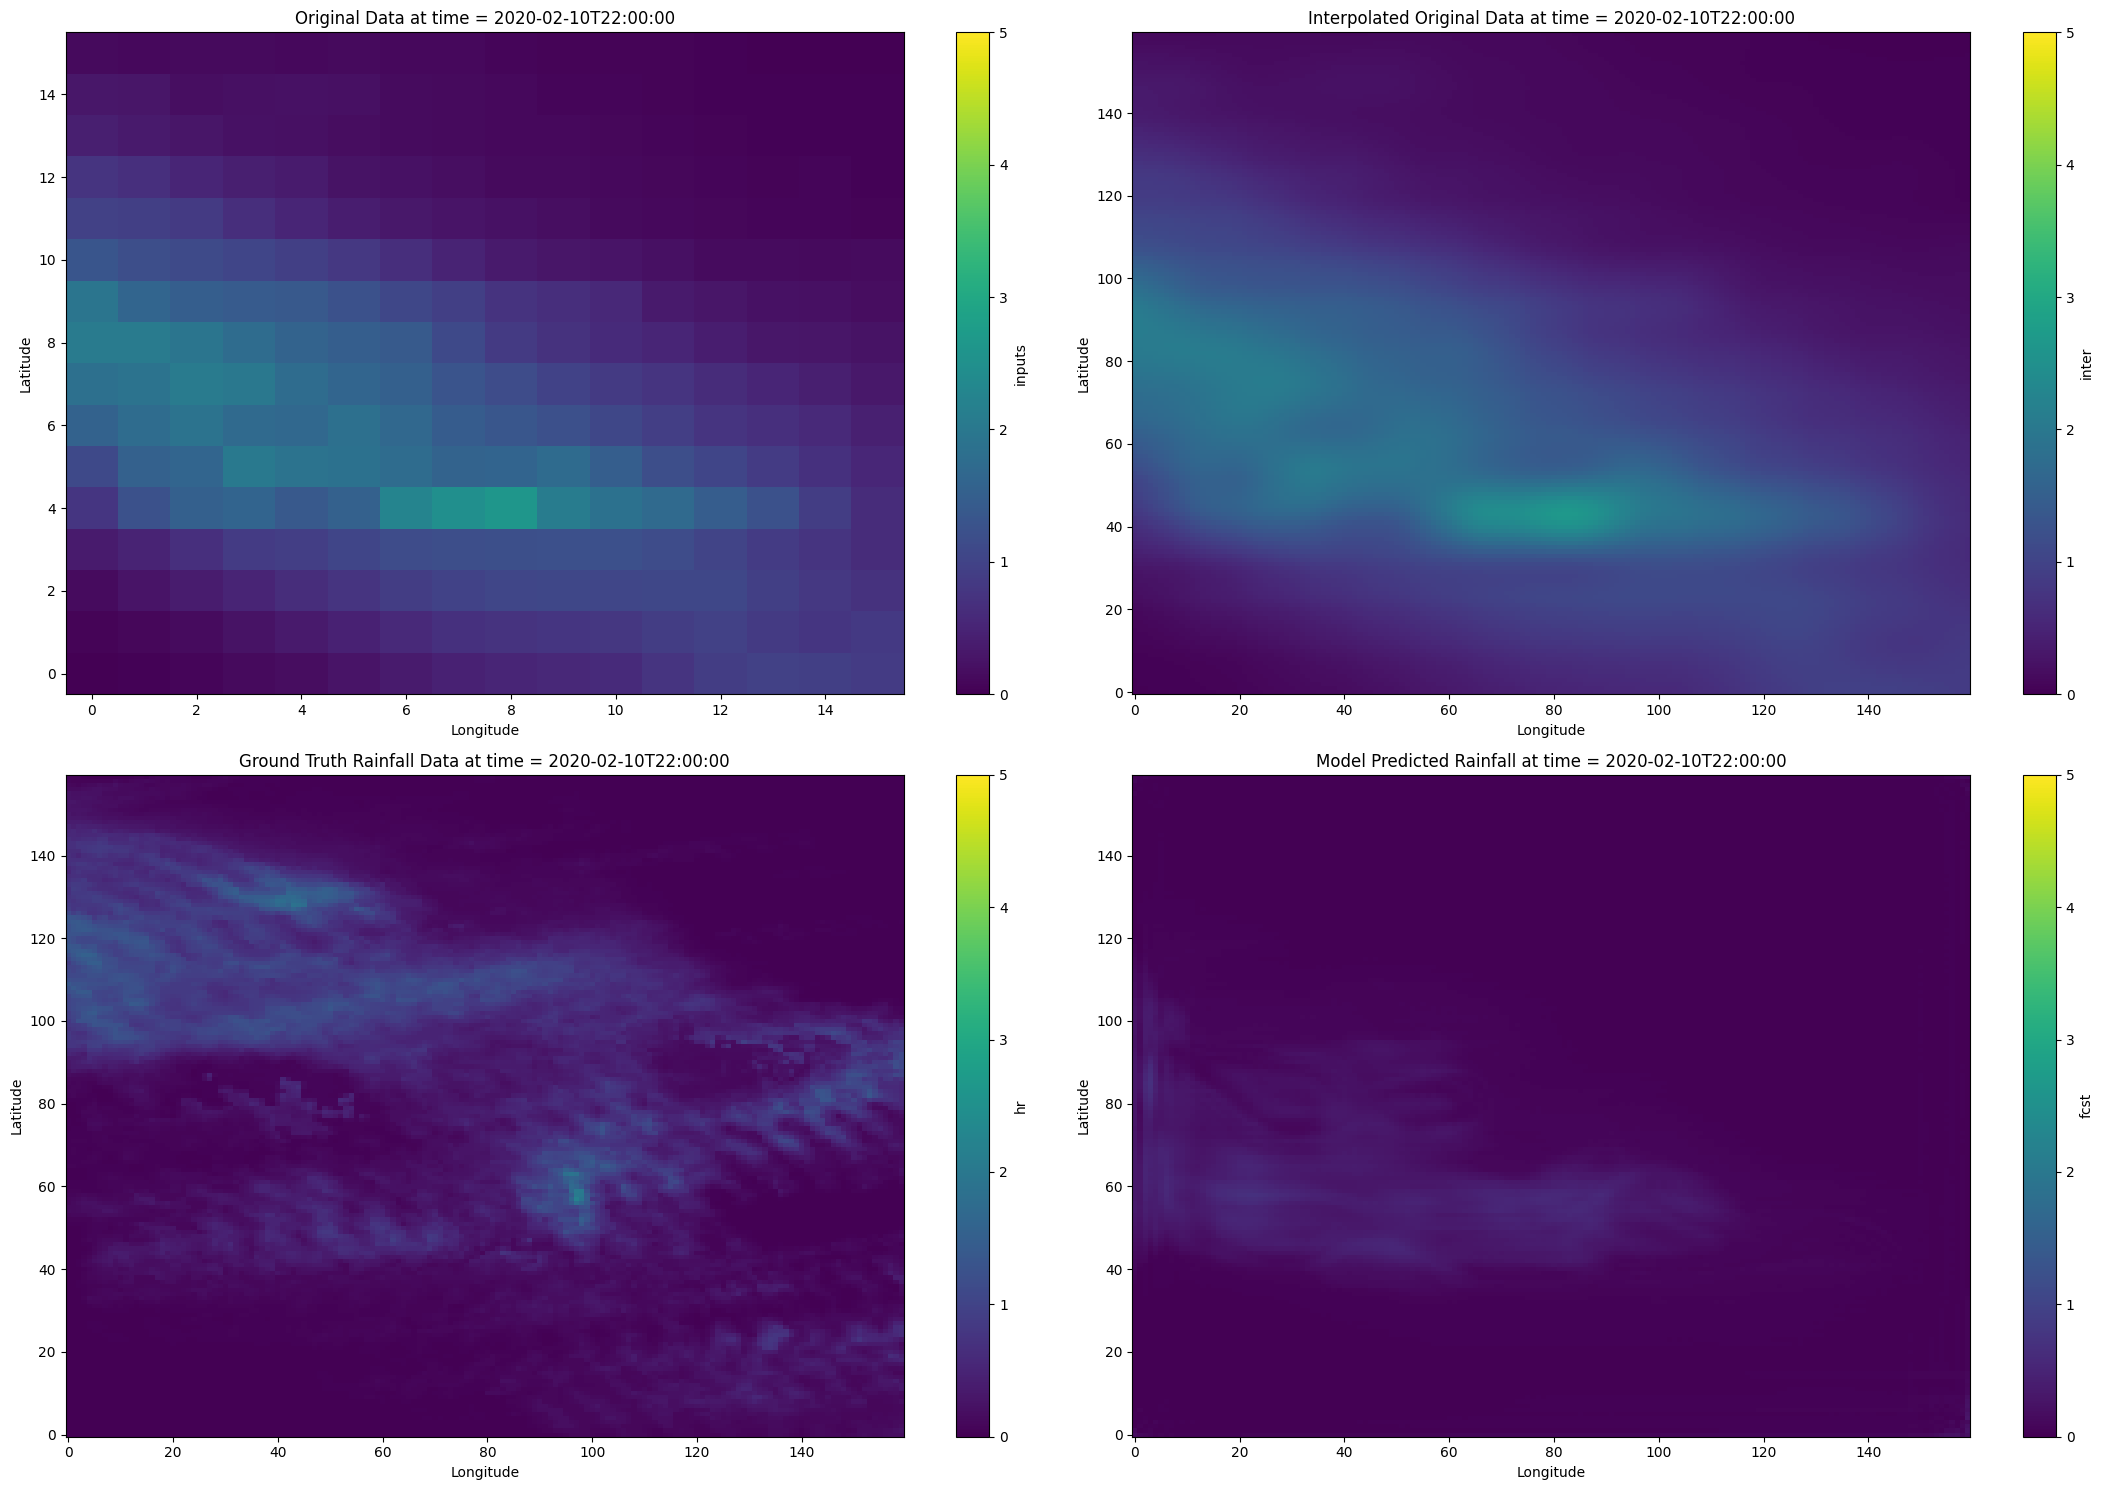

In [2]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# 加载数据集
dn = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex7_3_onestep_l1_nofc_aheadtop_50/prcp_downs_unet_year_2020.nc")
time_index = 650 #530 290 610 580 350 6200 5000     #650 380 3600 4500 30 60 460 920 1660 2420 2780 2940 3020 3080 3920 5190 5410 2940 650
time = pd.to_datetime(dn["time"].values[time_index]).isoformat()

# 创建两行两列的图布局
fig, axes = plt.subplots(2, 2, figsize=(22,15))

# 第一个图：原始数据
dn["inputs"].isel(time=time_index).plot(ax=axes[0, 0], vmin=0, vmax=5)
axes[0, 0].set_title(f'Original Data at time = {time}')
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')

# 第二个图：原始数据的插值
dn["inter"].isel(time=time_index).plot(ax=axes[0, 1], vmin=0, vmax=5)
axes[0, 1].set_title(f'Interpolated Original Data at time = {time}')
axes[0, 1].set_xlabel('Longitude')
axes[0, 1].set_ylabel('Latitude')

# 第三个图：真实数据（雷达）
dn["hr"].isel(time=time_index).plot(ax=axes[1, 0], vmin=0, vmax=5)
axes[1, 0].set_title(f'Ground Truth Rainfall Data at time = {time}')
axes[1, 0].set_xlabel('Longitude')
axes[1, 0].set_ylabel('Latitude')

# 第四个图：模型预测的降水数据
dn["fcst"].isel(time=time_index).plot(ax=axes[1, 1], vmin=0, vmax=5)
axes[1, 1].set_title(f'Model Predicted Rainfall at time = {time}')
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()


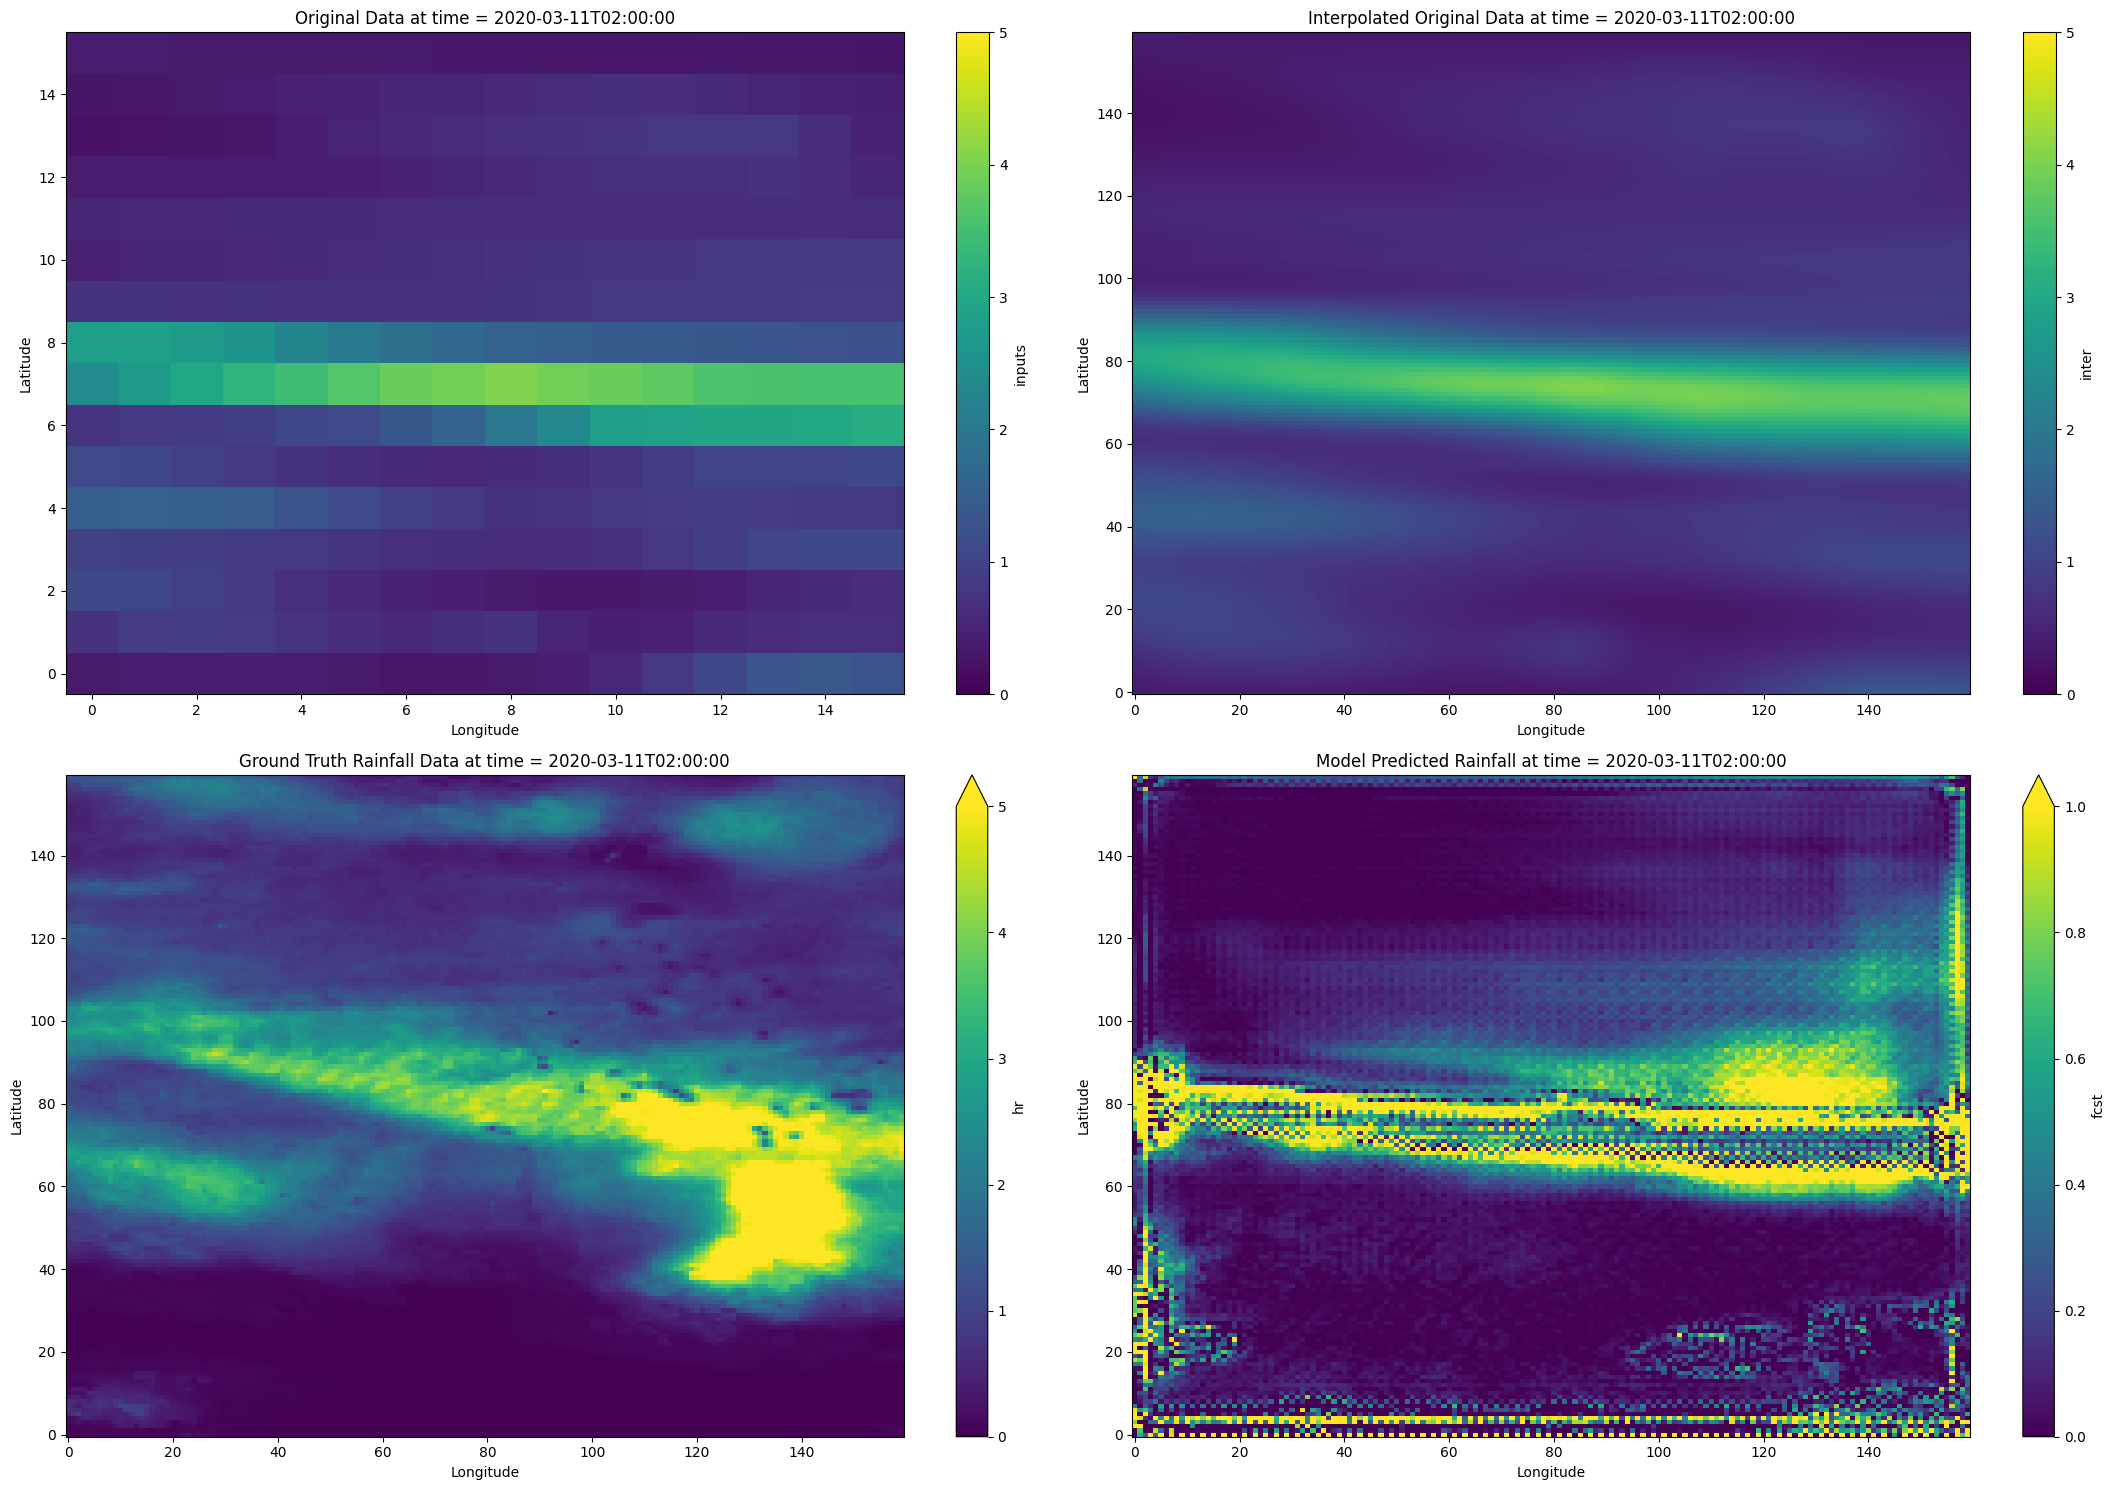

In [7]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# 加载数据集
dn = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_3_onestepwgan_cri5_181_025_l1_aheadtop_10_180epoch/prcp_downs_wgan_year_2020.nc")
time_index = 2420 #530 290 610 580 350 6200 5000     #650 380 3600 4500 30 60 460 920 1660 2420 2780 2940 3020 3080 3920 5190 5410 2940 650
time = pd.to_datetime(dn["time"].values[time_index]).isoformat()

# 创建两行两列的图布局
fig, axes = plt.subplots(2, 2, figsize=(22,15))

# 第一个图：原始数据
dn["inputs"].isel(time=time_index).plot(ax=axes[0, 0], vmin=0, vmax=5)
axes[0, 0].set_title(f'Original Data at time = {time}')
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')

# 第二个图：原始数据的插值
dn["inter"].isel(time=time_index).plot(ax=axes[0, 1], vmin=0, vmax=5)
axes[0, 1].set_title(f'Interpolated Original Data at time = {time}')
axes[0, 1].set_xlabel('Longitude')
axes[0, 1].set_ylabel('Latitude')

# 第三个图：真实数据（雷达）
dn["hr"].isel(time=time_index).plot(ax=axes[1, 0], vmin=0, vmax=5)
axes[1, 0].set_title(f'Ground Truth Rainfall Data at time = {time}')
axes[1, 0].set_xlabel('Longitude')
axes[1, 0].set_ylabel('Latitude')

# 第四个图：模型预测的降水数据
dn["fcst"].isel(time=time_index).plot(ax=axes[1, 1], vmin=0, vmax=1)
axes[1, 1].set_title(f'Model Predicted Rainfall at time = {time}')
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()


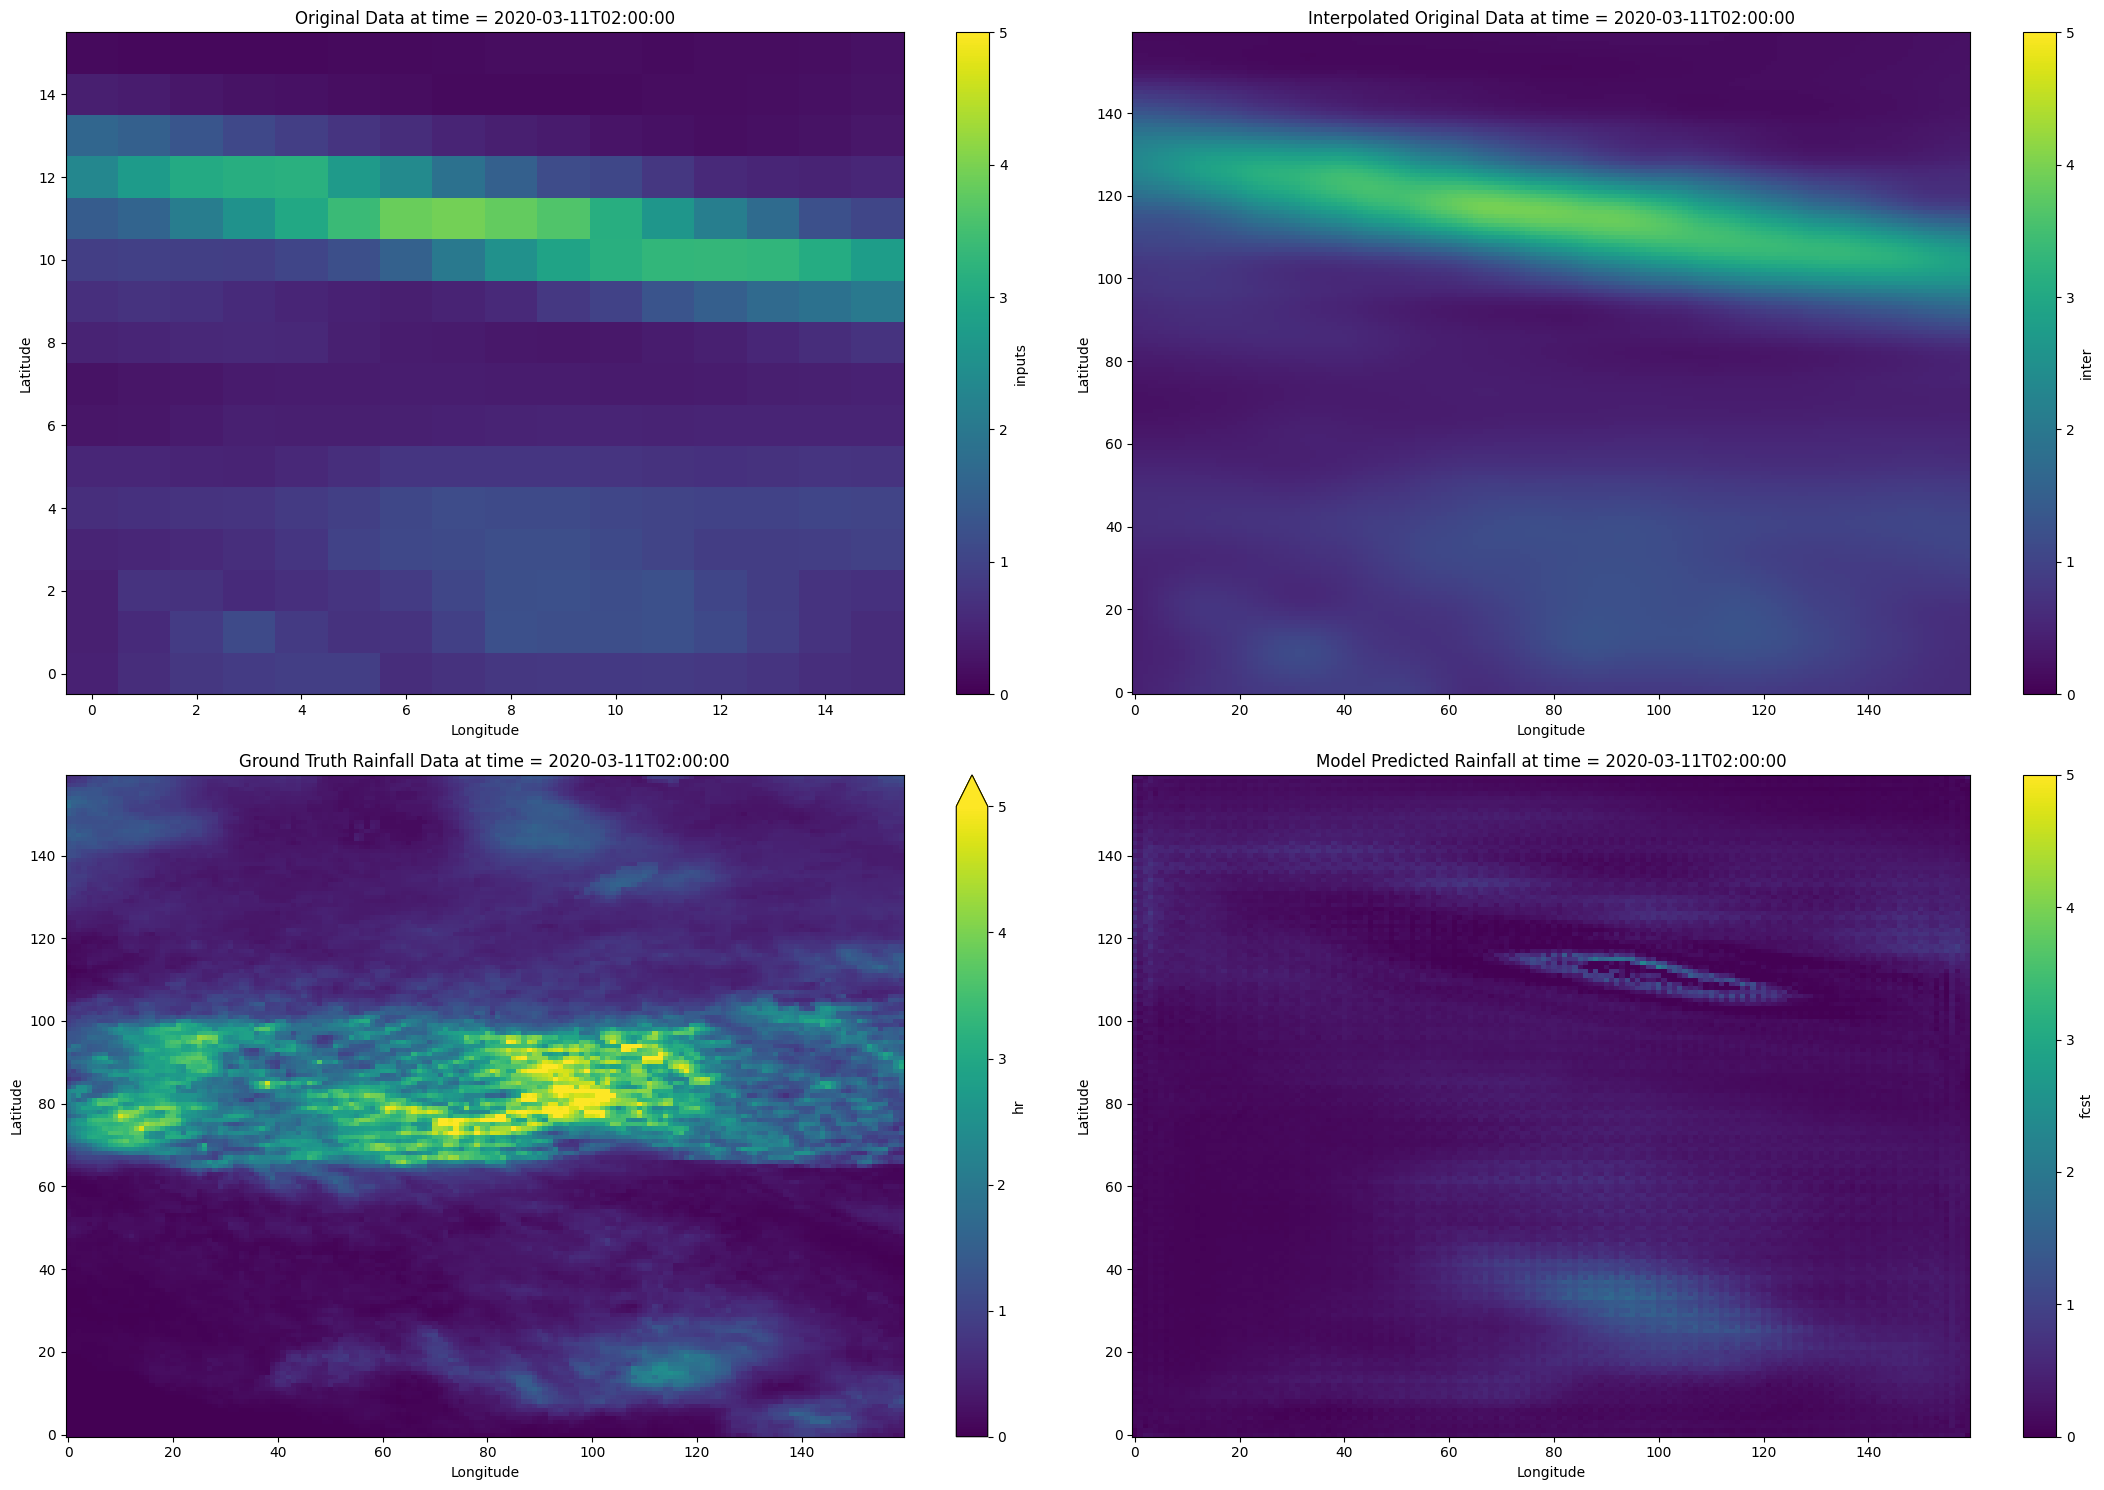

In [3]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# 加载数据集
dn = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_4_onestepwgan_cri5_181_025_l1_aheadtop_40_180epoch/prcp_downs_wgan_year_2020.nc")
time_index = 2424 #530 290 610 580 350 6200 5000     #650 380 3600 4500 30 60 460 920 1660 2420 2780 2940 3020 3080 3920 5190 5410 2940 650
time = pd.to_datetime(dn["time"].values[time_index]).isoformat()

# 创建两行两列的图布局
fig, axes = plt.subplots(2, 2, figsize=(22,15))

# 第一个图：原始数据
dn["inputs"].isel(time=time_index).plot(ax=axes[0, 0], vmin=0, vmax=5)
axes[0, 0].set_title(f'Original Data at time = {time}')
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')

# 第二个图：原始数据的插值
dn["inter"].isel(time=time_index).plot(ax=axes[0, 1], vmin=0, vmax=5)
axes[0, 1].set_title(f'Interpolated Original Data at time = {time}')
axes[0, 1].set_xlabel('Longitude')
axes[0, 1].set_ylabel('Latitude')

# 第三个图：真实数据（雷达）
dn["hr"].isel(time=time_index).plot(ax=axes[1, 0], vmin=0, vmax=5)
axes[1, 0].set_title(f'Ground Truth Rainfall Data at time = {time}')
axes[1, 0].set_xlabel('Longitude')
axes[1, 0].set_ylabel('Latitude')

# 第四个图：模型预测的降水数据
dn["fcst"].isel(time=time_index).plot(ax=axes[1, 1], vmin=0, vmax=5)
axes[1, 1].set_title(f'Model Predicted Rainfall at time = {time}')
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()


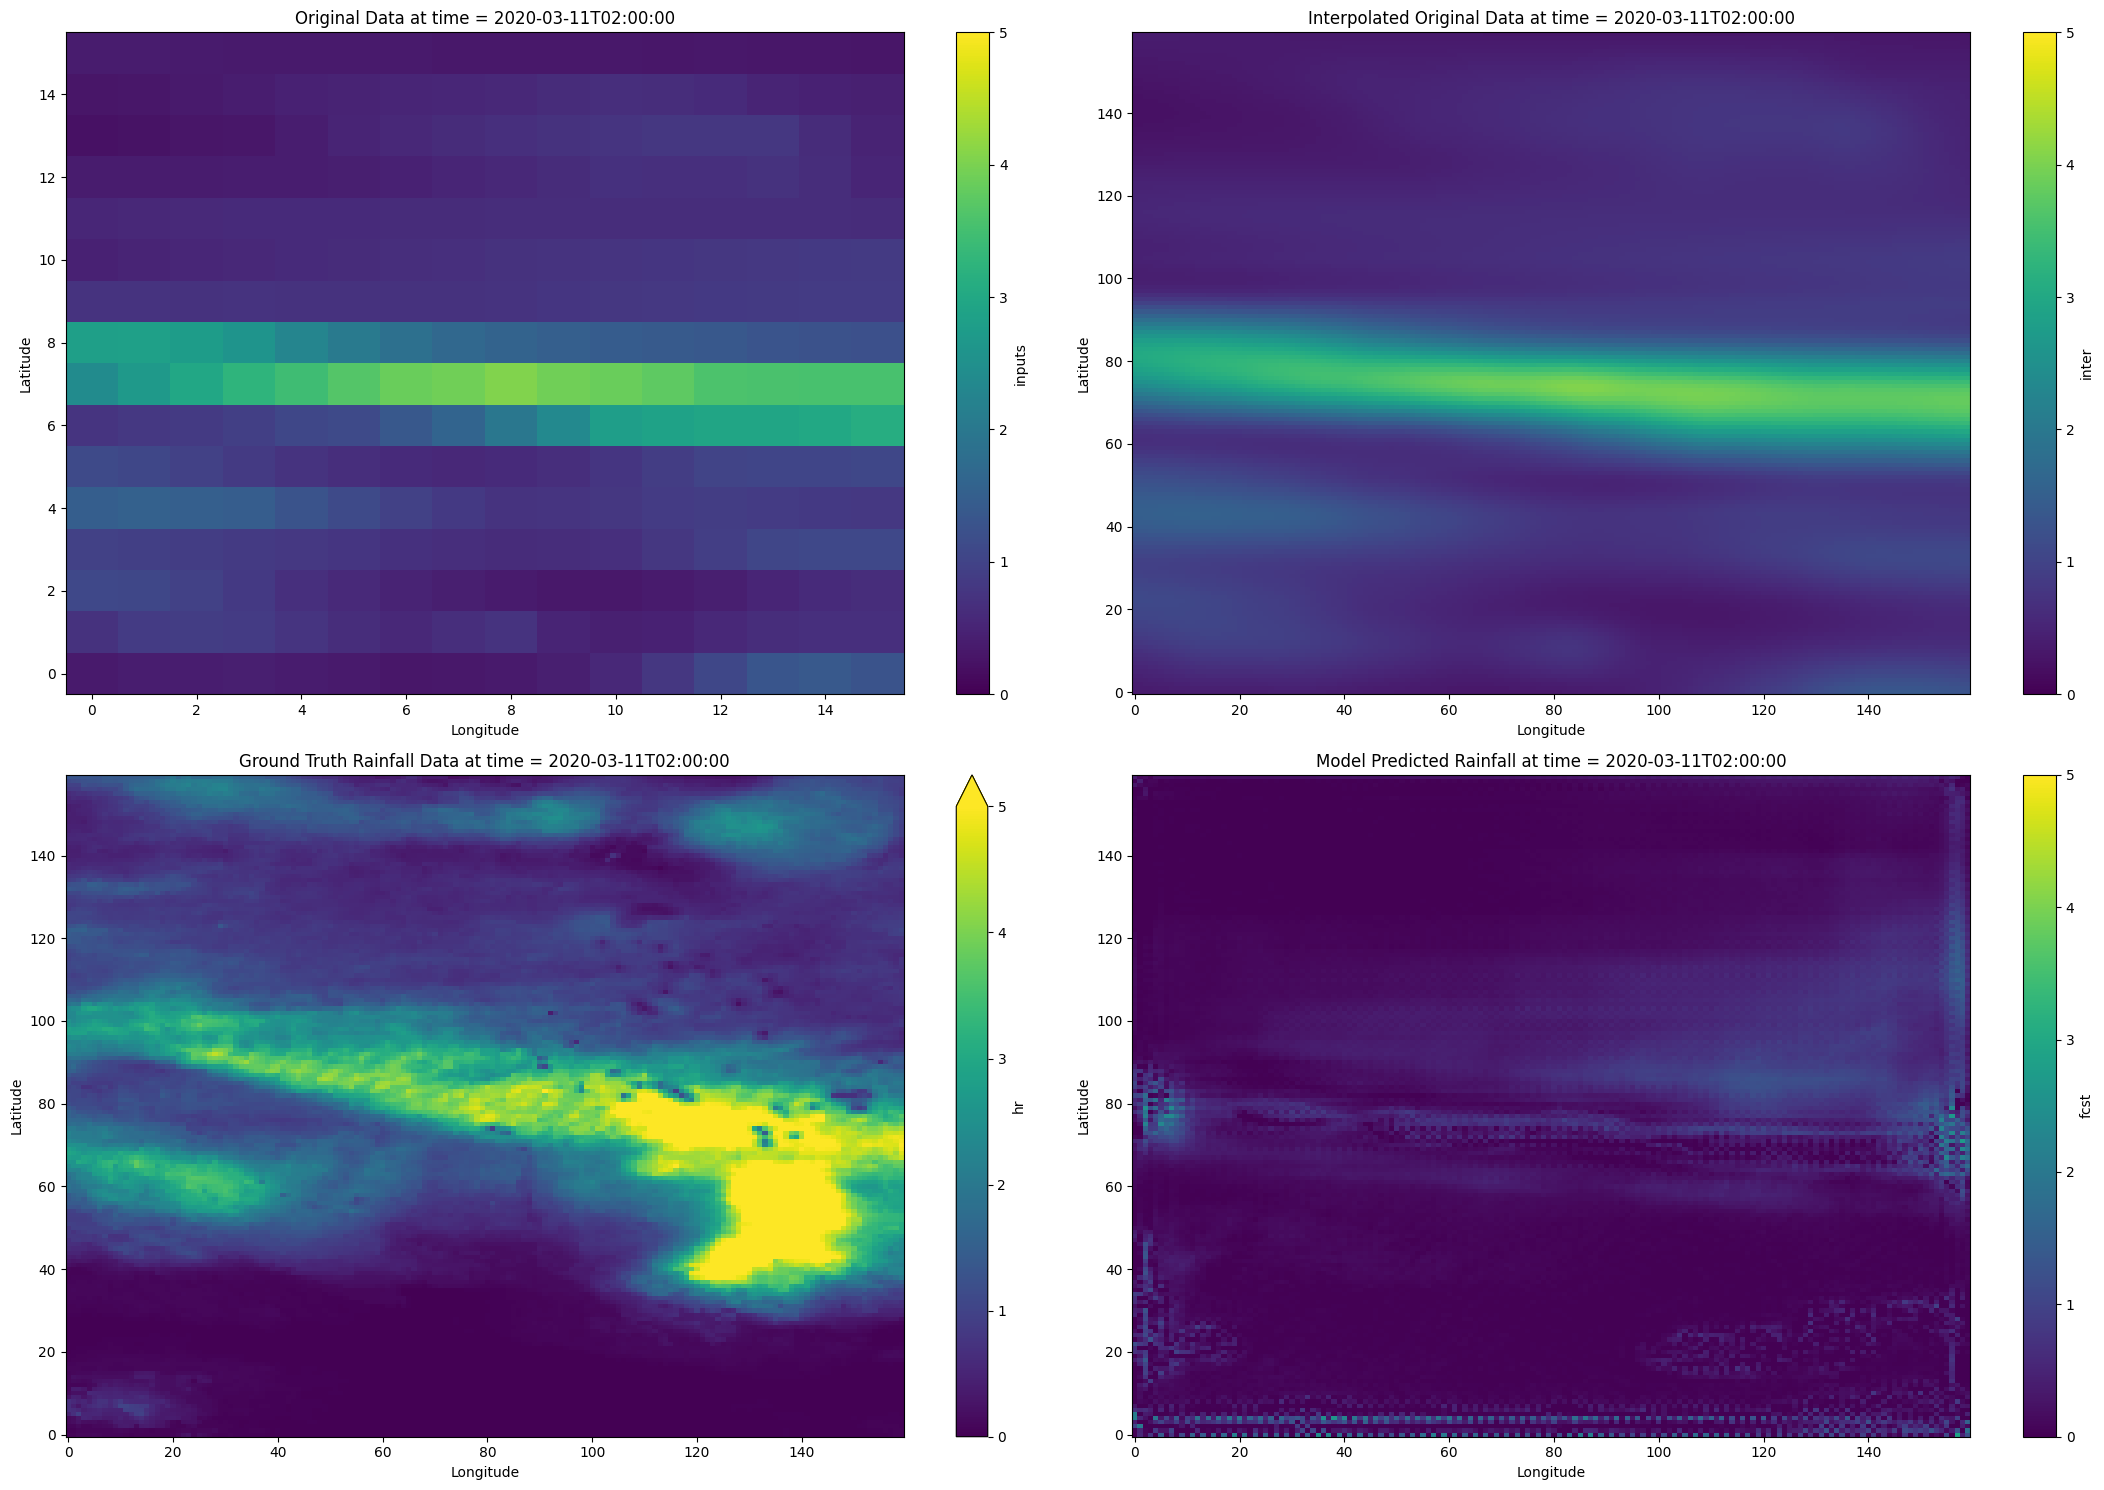

In [4]:

import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

# 加载数据集
dn = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_5_onestepwgan_cri5_1500_025_l1_aheadtop_10_180epoch/prcp_downs_wgan_year_2020.nc")
time_index = 2420 #530 290 610 580 350 6200 5000     #650 380 3600 4500 30 60 460 920 1660 2420 2780 2940 3020 3080 3920 5190 5410 2940 650
time = pd.to_datetime(dn["time"].values[time_index]).isoformat()

# 创建两行两列的图布局
fig, axes = plt.subplots(2, 2, figsize=(22,15))

# 第一个图：原始数据
dn["inputs"].isel(time=time_index).plot(ax=axes[0, 0], vmin=0, vmax=5)
axes[0, 0].set_title(f'Original Data at time = {time}')
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')

# 第二个图：原始数据的插值
dn["inter"].isel(time=time_index).plot(ax=axes[0, 1], vmin=0, vmax=5)
axes[0, 1].set_title(f'Interpolated Original Data at time = {time}')
axes[0, 1].set_xlabel('Longitude')
axes[0, 1].set_ylabel('Latitude')

# 第三个图：真实数据（雷达）
dn["hr"].isel(time=time_index).plot(ax=axes[1, 0], vmin=0, vmax=5)
axes[1, 0].set_title(f'Ground Truth Rainfall Data at time = {time}')
axes[1, 0].set_xlabel('Longitude')
axes[1, 0].set_ylabel('Latitude')

# 第四个图：模型预测的降水数据
dn["fcst"].isel(time=time_index).plot(ax=axes[1, 1], vmin=0, vmax=5)
axes[1, 1].set_title(f'Model Predicted Rainfall at time = {time}')
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()


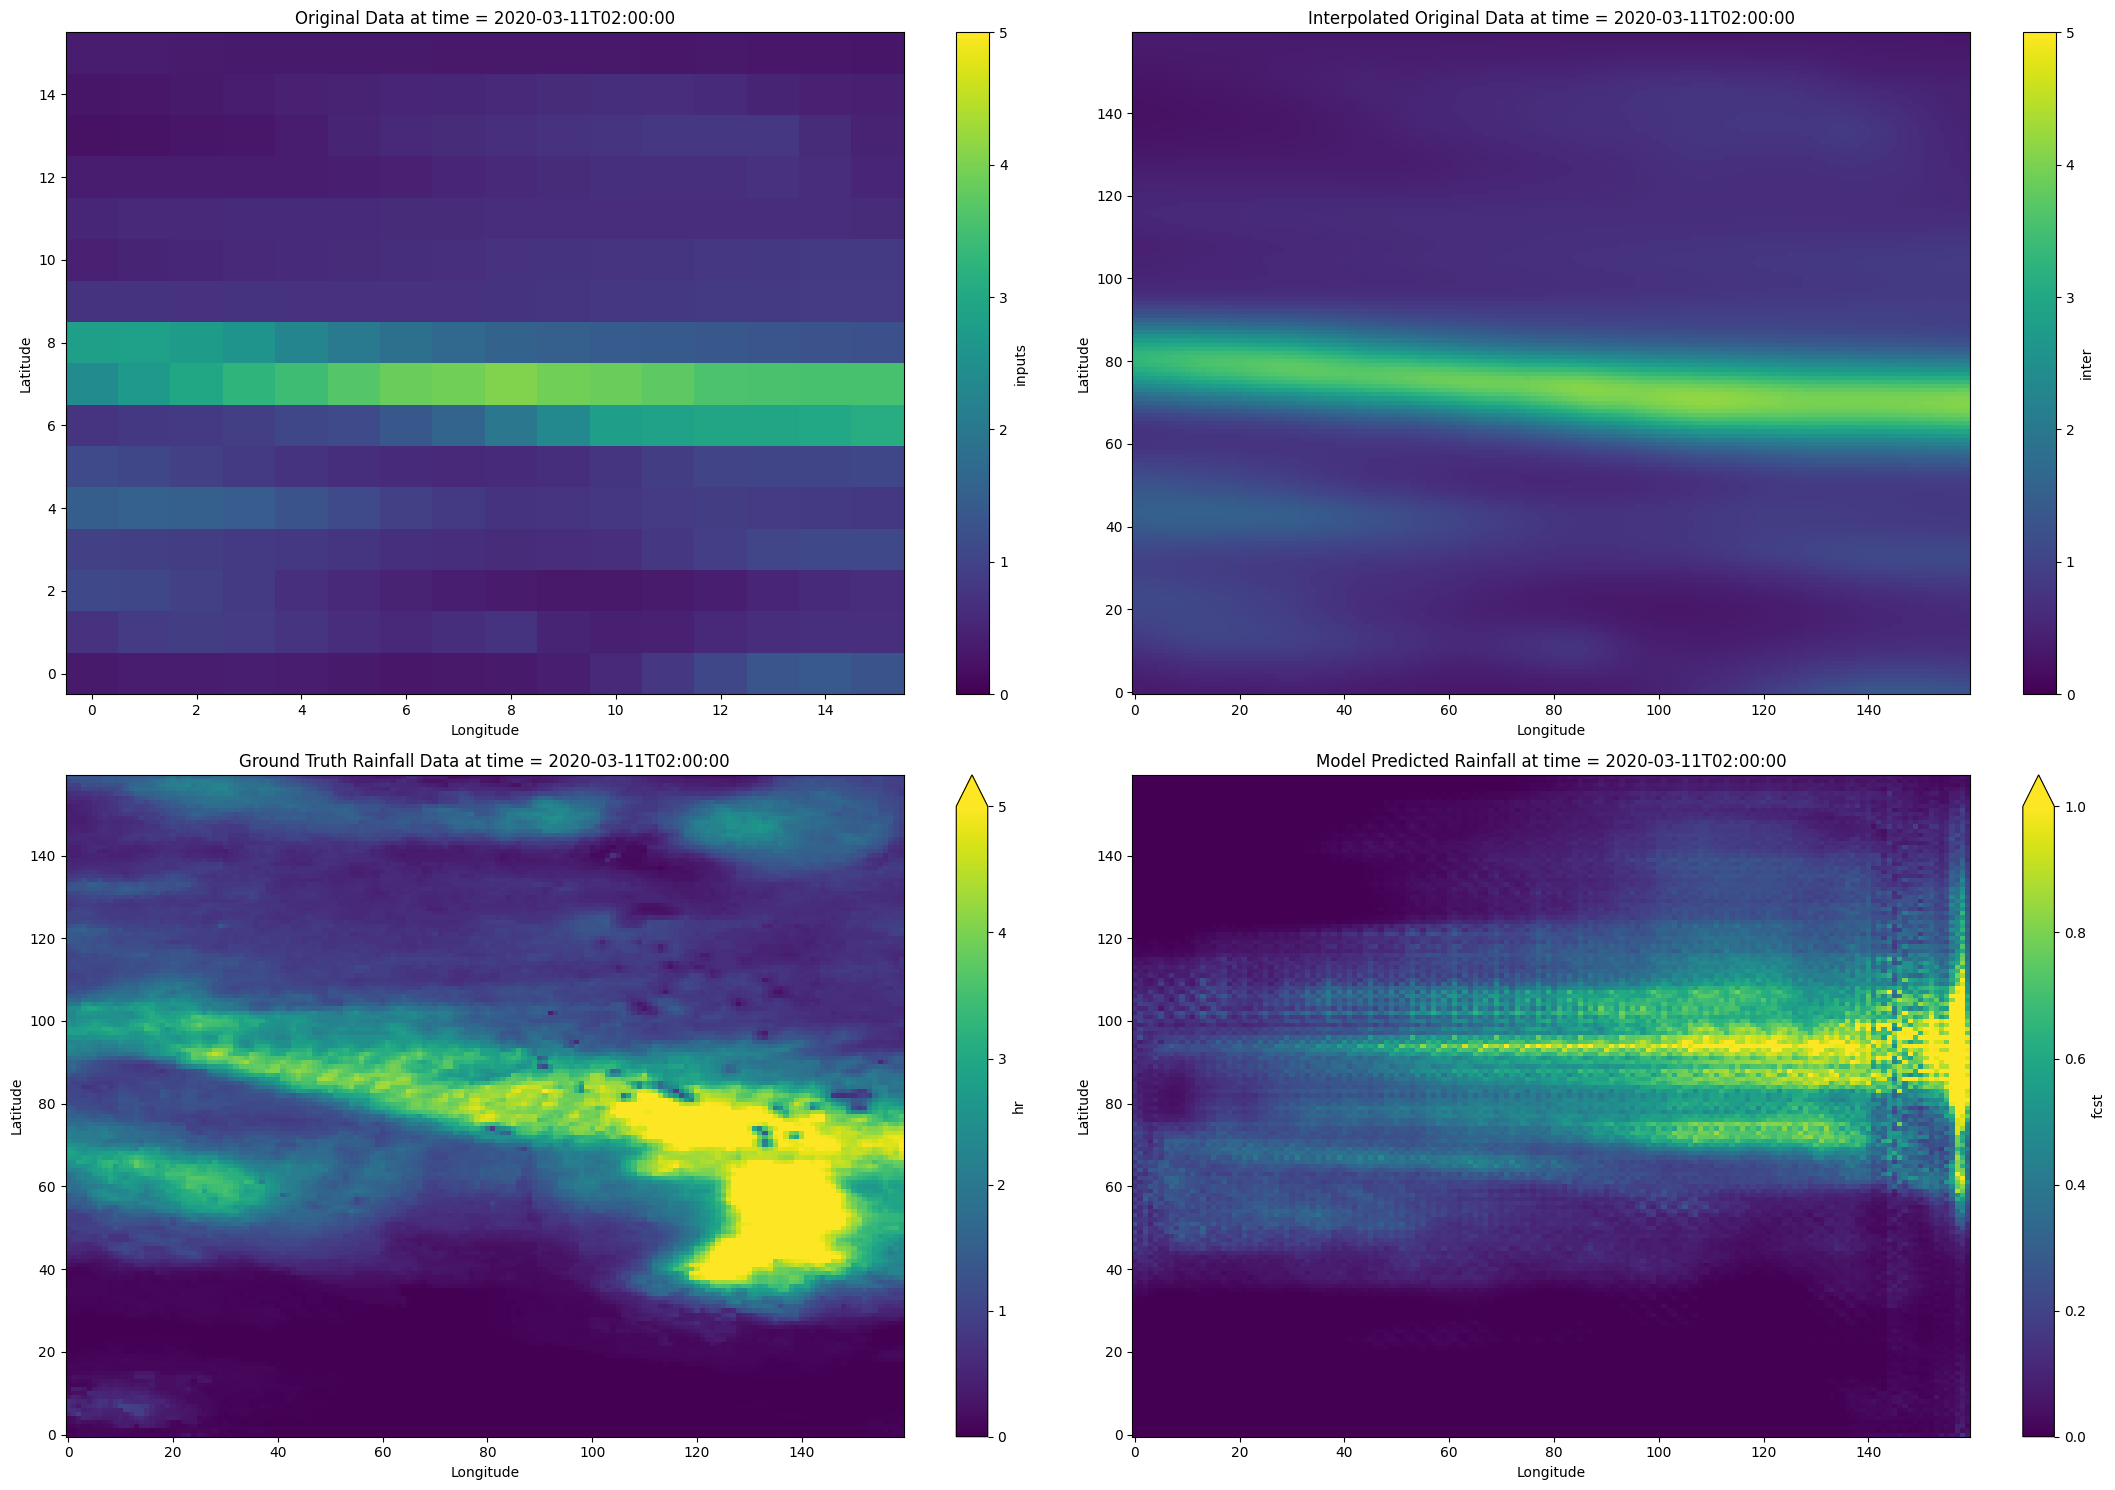

In [8]:
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# 加载数据集
dn = xr.open_dataset("/cpfs01/projects-HDD/cfff-4a8d9af84f66_HDD/public/ShiXiSheng/yzy/yzy_results/ex31_1_onestepwgan_cri5_181_025_l1_aheadtop_0.008_130epoch/prcp_downs_wgan_year_2020.nc")
time_index = 2420 #530 290 610 580 350 6200 5000     #650 380 3600 4500 30 60 460 920 1660 2420 2780 2940 3020 3080 3920 5190 5410 2940 650
time = pd.to_datetime(dn["time"].values[time_index]).isoformat()

# 创建两行两列的图布局
fig, axes = plt.subplots(2, 2, figsize=(22,15))

# 第一个图：原始数据
dn["inputs"].isel(time=time_index).plot(ax=axes[0, 0], vmin=0, vmax=5)
axes[0, 0].set_title(f'Original Data at time = {time}')
axes[0, 0].set_xlabel('Longitude')
axes[0, 0].set_ylabel('Latitude')

# 第二个图：原始数据的插值
dn["inter"].isel(time=time_index).plot(ax=axes[0, 1], vmin=0, vmax=5)
axes[0, 1].set_title(f'Interpolated Original Data at time = {time}')
axes[0, 1].set_xlabel('Longitude')
axes[0, 1].set_ylabel('Latitude')

# 第三个图：真实数据（雷达）
dn["hr"].isel(time=time_index).plot(ax=axes[1, 0], vmin=0, vmax=5)
axes[1, 0].set_title(f'Ground Truth Rainfall Data at time = {time}')
axes[1, 0].set_xlabel('Longitude')
axes[1, 0].set_ylabel('Latitude')

# 第四个图：模型预测的降水数据
dn["fcst"].isel(time=time_index).plot(ax=axes[1, 1], vmin=0, vmax=1)
axes[1, 1].set_title(f'Model Predicted Rainfall at time = {time}')
axes[1, 1].set_xlabel('Longitude')
axes[1, 1].set_ylabel('Latitude')

plt.tight_layout()
plt.show()
